# EDA with Species Data

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive/')

In [ ]:
# from google.colab import files
# import IPython

# files.upload()
# print("File(s) uploaded.")

In [ ]:
!pip install altair

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import pointbiserialr
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
from altair import datum

In [2]:
df =pd.read_parquet("species_8am_migration_weekend_weather_traffic.parquet")
df.columns

Index(['TAXONOMIC ORDER', 'CATEGORY', 'COMMON NAME', 'SCIENTIFIC NAME',
       'OBSERVATION COUNT', 'STATE CODE', 'LOCALITY TYPE', 'LATITUDE',
       'LONGITUDE', 'OBSERVATION DATE', 'TIME OBSERVATIONS STARTED',
       'SAMPLING EVENT IDENTIFIER', 'DURATION MINUTES', 'hour_started',
       'i95_distance', 'station_distances', 'assigned_station',
       'extreme_weather', 'year_record', 'month_record', 'day_record',
       'day_of_week', 'is_weekend', 'is_migration', 'Scientific_Name', 'Order',
       'state_code', 'station_id', 'daily_avg_noise', 'peak_hour_noise',
       'overnight_noise', 'rush_hour_noise', 'total_daily_volume',
       'noise_8am'],
      dtype='object')

In [3]:
df.shape

(1854002, 34)

In [4]:
df['OBSERVATION DATE'].head()

0   2023-06-14
1   2023-06-14
2   2023-06-16
3   2023-06-14
4   2023-06-14
Name: OBSERVATION DATE, dtype: datetime64[ns]

In [5]:
df['STATE CODE'].value_counts()

STATE CODE
US-VA    1216815
US-ME     637187
Name: count, dtype: int64

### Defining study data

In [7]:
data = df[['COMMON NAME', 'OBSERVATION COUNT', 'STATE CODE', 'LOCALITY TYPE',
             'i95_distance', 'assigned_station', 'year_record', 'month_record',
             'day_record', 'hour_started', 'daily_avg_noise', 'overnight_noise',
             'total_daily_volume','noise_8am', 'is_weekend', 'is_migration',
             'extreme_weather', 'Order']]

In [6]:
data.shape

(1854002, 18)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1854002 entries, 0 to 1854001
Data columns (total 18 columns):
 #   Column              Dtype  
---  ------              -----  
 0   COMMON NAME         object 
 1   OBSERVATION COUNT   object 
 2   STATE CODE          object 
 3   LOCALITY TYPE       object 
 4   i95_distance        float64
 5   assigned_station    object 
 6   year_record         int32  
 7   month_record        int32  
 8   day_record          int32  
 9   hour_started        float64
 10  daily_avg_noise     float64
 11  overnight_noise     float64
 12  total_daily_volume  float64
 13  noise_8am           float64
 14  is_weekend          int64  
 15  is_migration        int64  
 16  extreme_weather     int64  
 17  Order               object 
dtypes: float64(6), int32(3), int64(3), object(6)
memory usage: 233.4+ MB


"station distance" (dict object) will not be included in this feature study.

### Data transformations for graphing

#### Target

In [7]:
target = data["OBSERVATION COUNT"]

In [8]:
data['OBSERVATION COUNT'].value_counts().nlargest(10)

OBSERVATION COUNT
1     692066
2     390856
3     180979
4     127395
5      81062
6      64701
X      41665
8      36437
7      33336
10     25534
Name: count, dtype: int64

In [ ]:
# Cleaning up 41K nonnumeric data ("X") from our target
data['OBSERVATION COUNT'] = pd.to_numeric(data['OBSERVATION COUNT'], errors='coerce')
# Dropping non-numeric 'OBSERVATION COUNT' rows
data = data.dropna(subset=['OBSERVATION COUNT'])
data.shape

### Grouping features by type for graphing

In [8]:
numeric_features = data[['OBSERVATION COUNT','i95_distance', 'daily_avg_noise', 'overnight_noise',
                         'total_daily_volume', 'noise_8am']]

In [27]:
binary_features = ['OBSERVATION COUNT','STATE CODE', 'is_weekend', 'is_migration', "extreme_weather"]


In [28]:
categorical_features = data[['OBSERVATION COUNT','COMMON NAME','LOCALITY TYPE', 'year_record',
                             'month_record', 'day_record', 'assigned_station', 'Order' ]]

**Numeric Features**

In [9]:
numeric_features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1812337 entries, 0 to 1854001
Data columns (total 6 columns):
 #   Column              Dtype  
---  ------              -----  
 0   OBSERVATION COUNT   float64
 1   i95_distance        float64
 2   daily_avg_noise     float64
 3   overnight_noise     float64
 4   total_daily_volume  float64
 5   noise_8am           float64
dtypes: float64(6)
memory usage: 96.8 MB


In [31]:
numeric_features.shape

(1854002, 5)

In [25]:
# confirm all rows are 8 am record
data.hour_started.value_counts()

,count
hour_started,
8.0,1812337


In [32]:
# Check for null value
numeric_features.noise_8am.isnull().value_counts()

,count
noise_8am,
False,1578007
True,275995


In [10]:
# Drop null values
numeric_features = numeric_features.dropna()
numeric_features.shape

(1541132, 6)

### Heat Maps

#### Numeric Features

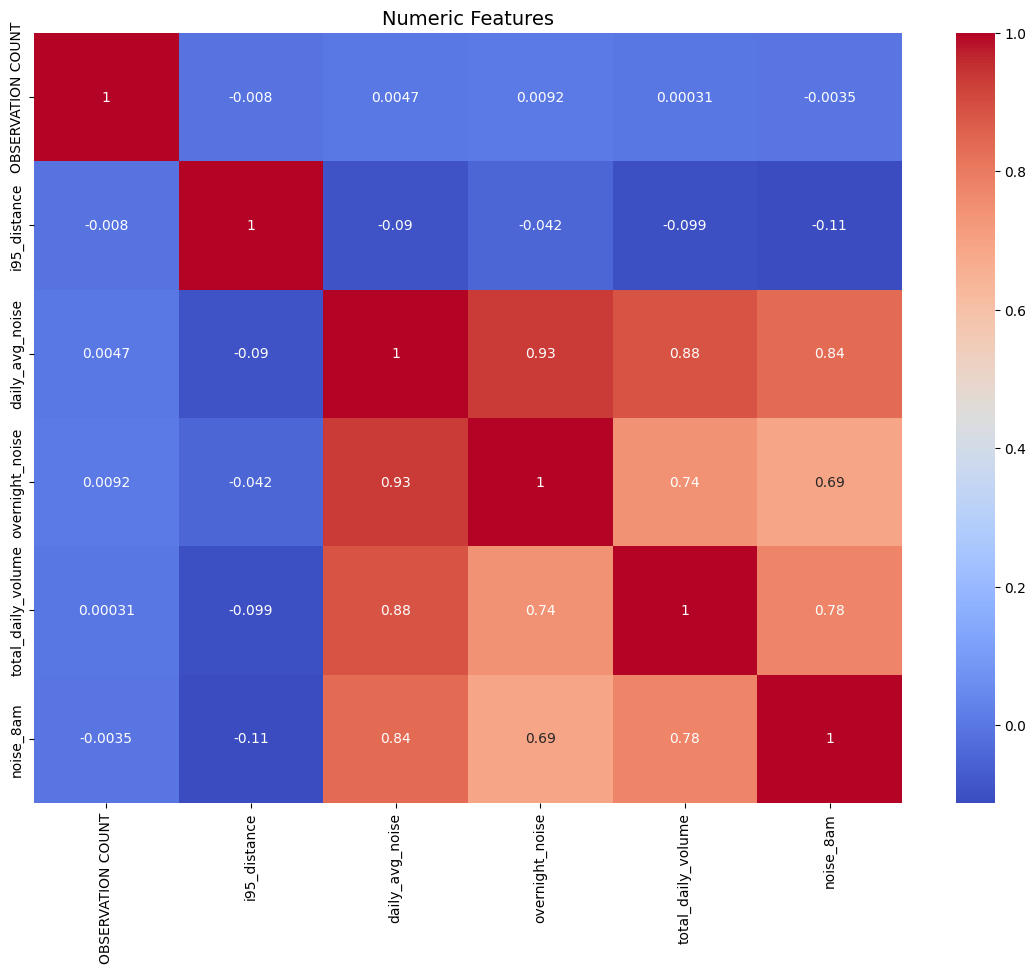

In [62]:
graph_data = numeric_features.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(graph_data, cmap="coolwarm", annot=True)
plt.title('Numeric Features', fontsize=14)
plt.xticks(rotation=90)
plt.show()

In [43]:
numeric_features.columns

Index(['OBSERVATION COUNT', 'i95_distance', 'daily_avg_noise',
       'overnight_noise', 'total_daily_volume', 'noise_8am'],
      dtype='object')

In [10]:
numerical_features = numeric_features.drop(columns=['OBSERVATION COUNT'])

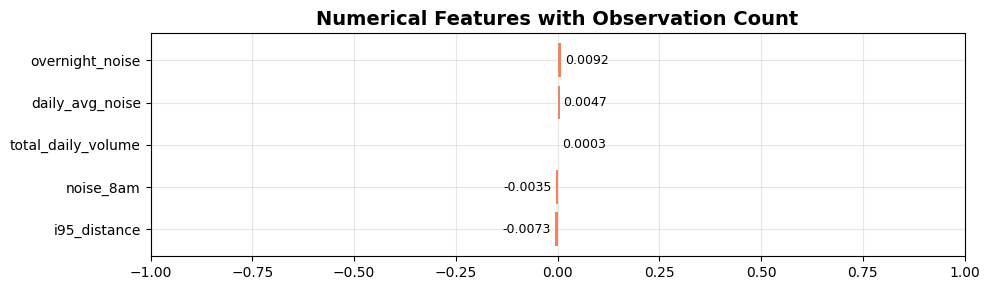

In [80]:
# New Correlation Plot

import matplotlib.pyplot as plt
import pandas as pd

# Calculate correlation with target variable
corr_with_target = numeric_features.corr()['OBSERVATION COUNT'].sort_values(ascending=False)
corr_with_target = corr_with_target.drop('OBSERVATION COUNT')  # Remove self-correlation

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 3))

# Create horizontal bar plot
bars = ax.barh(range(len(corr_with_target)), corr_with_target.values, color='coral')

# Add value labels on the bars
for i, (bar, value) in enumerate(zip(bars, corr_with_target.values)):
    ax.text(value + 0.01 if value >= 0 else value - 0.01, i, f'{value:.4f}', 
            va='center', ha='left' if value >= 0 else 'right', fontsize=9)
ax.set_yticks(range(len(corr_with_target)))
ax.set_yticklabels(corr_with_target.index, fontsize=10)
ax.set_title('Numerical Features with Observation Count', fontsize=14, fontweight='bold')
# ax.set_xlabel('Correlation Coefficient')
ax.set_xlim(-1.0, 1.0)  # Set x-axis limits from -1 to 1
# ax.set_xticks([-1.0, -0.5, -0.1, 0, 0.1, 0.5, 1.0])  # Set specific tick positions

ax.grid(True, alpha=0.3)

# Invert y-axis to show highest correlations at the top
ax.invert_yaxis()

plt.tight_layout()
plt.show()

#### Binary Features

In [39]:
target = 'OBSERVATION COUNT'

In [36]:
# Function to draw correlation heatmap for binary features
def biserial_correlation_heatmap(df, binary_cols, target_col):
    correlations = {}

    for col in binary_cols:
        # Ensure binary columns are numeric 0/1 and converts to cat for corr calculation
        if df[col].dtype == 'object' or df[col].dtype.name == 'category':
            df[col] = df[col].astype('category').cat.codes

        corr, pval = pointbiserialr(df[col], df[target_col])
        correlations[col] = corr

    # Convert to DataFrame for heatmap
    corr_df = pd.DataFrame.from_dict(correlations, orient='index', columns=[f'Corr with {target_col}'])

    # heatmap
    plt.figure(figsize=(6, len(binary_cols)*0.6 + 2))
    sns.heatmap(corr_df, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
    plt.title(f'Point Biserial Correlation with Observation Count' , fontsize=14)
    plt.tight_layout()
    plt.show()

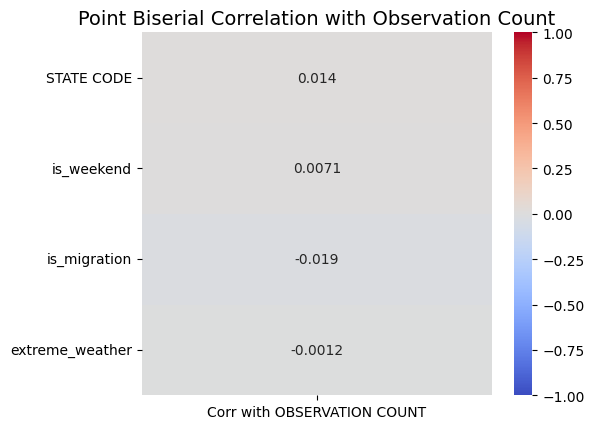

In [40]:
biserial_correlation_heatmap(data, binary_features, target)

#### Categorical & Temporal Features

In [29]:
# Processing temporal data
def preprocess_temporal_features(df, year_col='year_record', month_col='month_record',
                                 day_col='day_record'):

    df = df.copy()

    # Year: treat as categorical and numeric
    if year_col in df.columns:
        df[year_col] = pd.to_numeric(df[year_col], errors='coerce')
        df[f'{year_col}_cat'] = df[year_col].astype('category')

    # Month: add cyclical encoding with validation
    if month_col in df.columns:
        df[month_col] = pd.to_numeric(df[month_col], errors='coerce')

        # Cyclical encoding: subtract 1 to make it 0-11 for proper cycling
        month_normalized = (df[month_col] - 1) / 12  # 0-11 normalized to 0-1
        df['month_sin'] = np.sin(2 * np.pi * month_normalized)
        df['month_cos'] = np.cos(2 * np.pi * month_normalized)

    # Day of Month: add cyclical encoding with validation
    if day_col in df.columns:
        df[day_col] = pd.to_numeric(df[day_col], errors='coerce')

        # Validate day range (1-31)
        valid_days = df[day_col].between(1, 31)
        if not valid_days.all():
            invalid_count = (~valid_days & df[day_col].notna()).sum()
            print(f"Warning: {invalid_count} day values outside range 1-31")

        # Cyclical encoding: subtract 1 to make it 0-30, then normalize to 0-1
        day_normalized = (df[day_col] - 1) / 31  # 0-30 normalized to 0-1
        df['day_sin'] = np.sin(2 * np.pi * day_normalized)
        df['day_cos'] = np.cos(2 * np.pi * day_normalized)

    return df


In [30]:
cat_df = preprocess_temporal_features(categorical_features, year_col='year_record', month_col='month_record',
                                 day_col='day_record')

In [31]:
categorical_features.columns

Index(['OBSERVATION COUNT', 'COMMON NAME', 'LOCALITY TYPE', 'year_record',
       'month_record', 'day_record', 'assigned_station', 'Order'],
      dtype='object')

In [32]:
# Encode Categorical Columns
cat_df['common_name_encoded'] = LabelEncoder().fit_transform(cat_df['COMMON NAME'])
cat_df['locality_encoded'] = LabelEncoder().fit_transform(cat_df['LOCALITY TYPE'])
cat_df['assigned_station_encoded'] = LabelEncoder().fit_transform(cat_df['assigned_station'])
cat_df['order_encoded'] = LabelEncoder().fit_transform(cat_df['Order'])

In [72]:
cat_df.columns

Index(['OBSERVATION COUNT', 'COMMON NAME', 'LOCALITY TYPE', 'year_record',
       'month_record', 'day_record', 'assigned_station', 'Order',
       'year_record_cat', 'month_sin', 'month_cos', 'day_sin', 'day_cos',
       'common_name_encoded', 'locality_encoded', 'assigned_station_encoded',
       'order_encoded'],
      dtype='object')

In [47]:
cat_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1854002 entries, 0 to 1854001
Data columns (total 17 columns):
 #   Column                    Dtype   
---  ------                    -----   
 0   COMMON NAME               object  
 1   OBSERVATION COUNT         object  
 2   LOCALITY TYPE             object  
 3   year_record               int32   
 4   month_record              int32   
 5   day_record                int32   
 6   assigned_station          object  
 7   Order                     object  
 8   year_record_cat           category
 9   month_sin                 float64 
 10  month_cos                 float64 
 11  day_sin                   float64 
 12  day_cos                   float64 
 13  common_name_encoded       int64   
 14  locality_encoded          int64   
 15  assigned_station_encoded  int64   
 16  order_encoded             int64   
dtypes: category(1), float64(4), int32(3), int64(4), object(5)
memory usage: 206.9+ MB


In [36]:
cat_corr = cat_df.select_dtypes(include=[np.number])
cm = cat_corr.corr(method='pearson')
cm_target = cm['OBSERVATION COUNT'].sort_values(ascending=False)

In [74]:
cat_corr.columns

Index(['OBSERVATION COUNT', 'year_record', 'month_record', 'day_record',
       'month_sin', 'month_cos', 'day_sin', 'day_cos', 'common_name_encoded',
       'locality_encoded', 'assigned_station_encoded', 'order_encoded'],
      dtype='object')

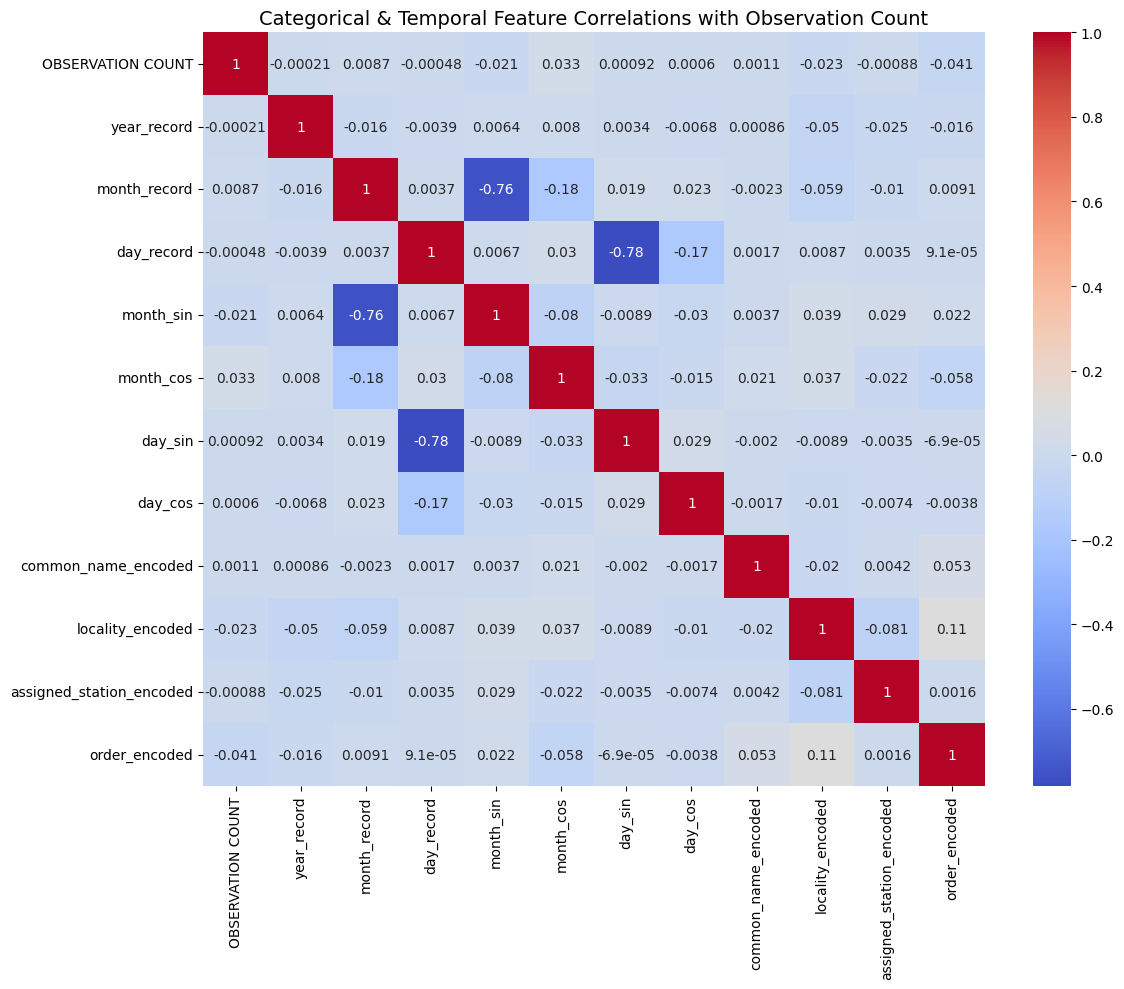

In [75]:
# Heat map
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, cmap='coolwarm')
plt.title(f'Categorical & Temporal Feature Correlations with Observation Count' , fontsize=14)
plt.tight_layout()
plt.show()

In [38]:
len(cm_target)

11

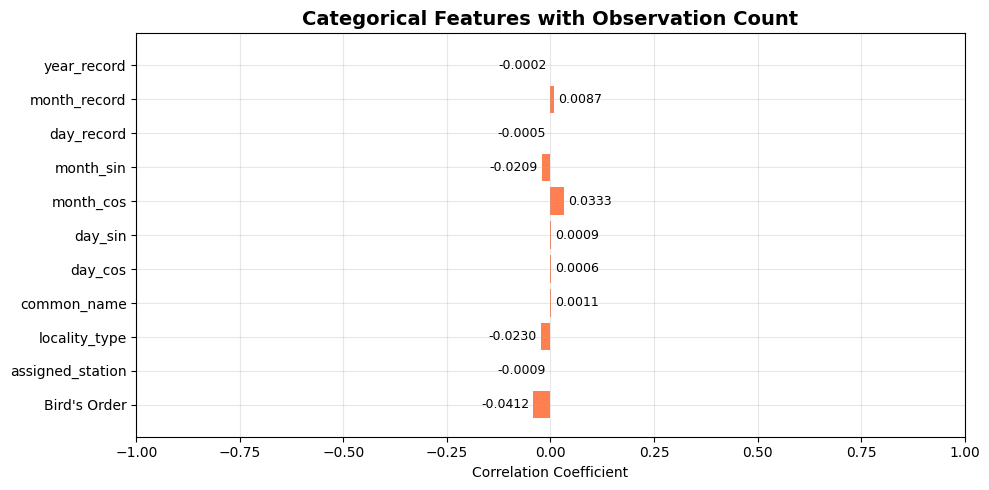

In [81]:
# Extract correlation with target variable
cm_target = cm['OBSERVATION COUNT'].drop('OBSERVATION COUNT')  # Remove self-correlation
label_mapping = {
    'common_name_encoded': 'common_name',
       'locality_encoded': 'locality_type', 
       'assigned_station_encoded': 'assigned_station', 
       'order_encoded': "Bird's Order"
}

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 5))

# Create horizontal bar plot
bars = ax.barh(range(len(cm_target)), cm_target.values, color='coral')

# Add value labels on the bars
for i, (bar, value) in enumerate(zip(bars, cm_target.values)):
    ax.text(value + 0.01 if value >= 0 else value - 0.01, i, f'{value:.4f}', 
            va='center', ha='left' if value >= 0 else 'right', fontsize=9)

ax.set_yticks(range(len(cm_target)))
custom_labels = [label_mapping.get(label, label) for label in cm_target.index]
ax.set_yticklabels(custom_labels, fontsize=10)
ax.set_title('Categorical Features with Observation Count', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
ax.set_xlim(-1.0, 1.0)
# ax.set_xticks([-0.5, -0.1, 0, 0.1, 0.5])
ax.grid(True, alpha=0.3)

# Invert y-axis to show highest correlations at the top
ax.invert_yaxis()

plt.tight_layout()
plt.show()

#### Findings
- Overall, all features being studied show very small correlation with our target ("OBSERVATION COUNT") indicating lack of linear relationship between the features and my target.
- "Order" shows highest correlation with targer at 0.04 but is still very small for any significant relationship.

### Scatter plots for more detailed relationship study

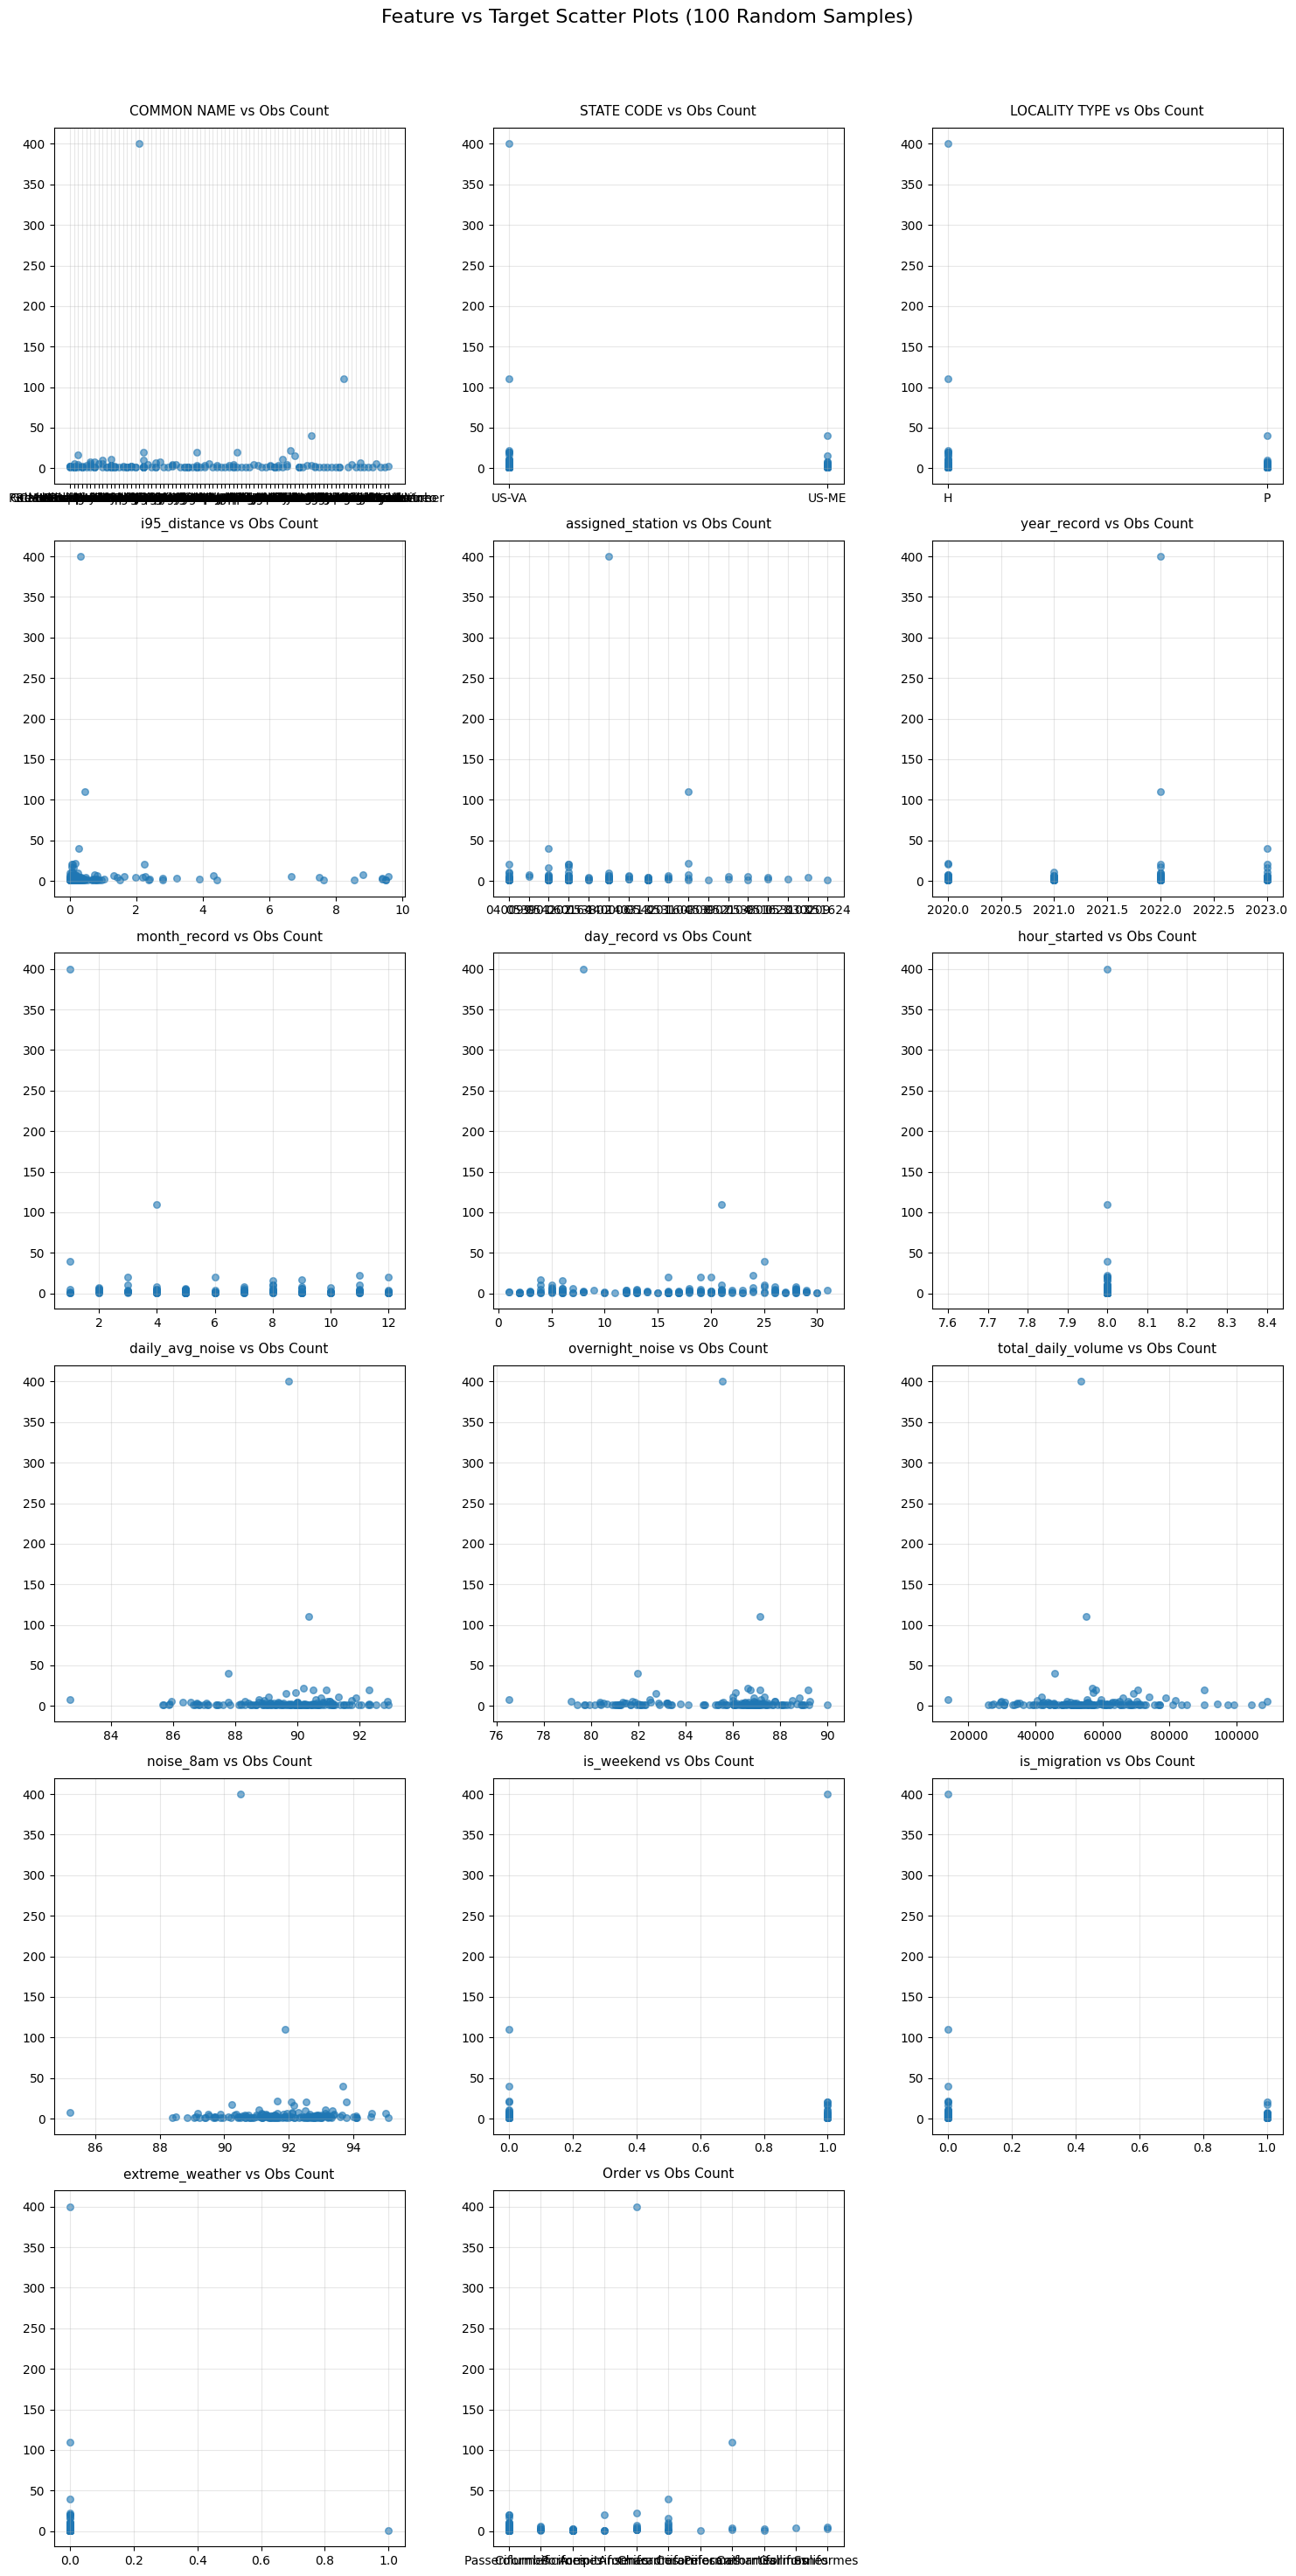

In [88]:
# Sample 100 random rows for graphing
df_sample = data.sample(n=200, random_state=42)
df_sample = df_sample.dropna()

feature_cols = [col for col in df_sample.columns if col != "OBSERVATION COUNT"]

n_features = len(feature_cols)
n_cols = 3  # Number of columns in the subplot grid
n_rows = (n_features + n_cols - 1) // n_cols  # Calculate required rows

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
fig.suptitle('Feature vs Target Scatter Plots (100 Random Samples)', fontsize=16)

# Flatten axes array for easier indexing
axes = axes.flatten() if n_features > 1 else [axes]

# Create scatter plots
for i, feature in enumerate(feature_cols):
    ax = axes[i]
    ax.scatter(df_sample[feature], df_sample["OBSERVATION COUNT"], alpha=0.6, s=30)
    # ax.set_xlabel(feature, fontsize=10)
    # ax.set_ylabel("Obs Cnt", fontsize=10)
    ax.set_title(f'{feature} vs {"Obs Count"}', fontsize=11, pad=10)
    ax.grid(True, alpha=0.3)
    # ax.tick_params(axis='both', which='major', labelsize=9)

# Hide empty subplots
for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Optional: Save the plot
# plt.savefig('feature_scatter_plots.png', dpi=300, bbox_inches='tight')

## Filtering for Songbird's Order

In [13]:
# Clean data
data.Order = data.Order.str.strip()

In [14]:
sb_data = data[data.Order == "Passeriformes"]

In [110]:
data.Order.value_counts().nlargest(3)

,count
Order,
Passeriformes,1100776
Piciformes,133896
Anseriformes,118430


In [15]:
sb_data.shape

(1100776, 18)

###Re-do heatmaps for filtered data

In [113]:
numeric_features2 = sb_data[['OBSERVATION COUNT','i95_distance', 'daily_avg_noise', 'overnight_noise',
                         'total_daily_volume', 'noise_8am']]
categorical_features2 = sb_data[['OBSERVATION COUNT','COMMON NAME','LOCALITY TYPE', 'year_record',
                             'month_record', 'day_record', 'assigned_station', 'Order' ]]

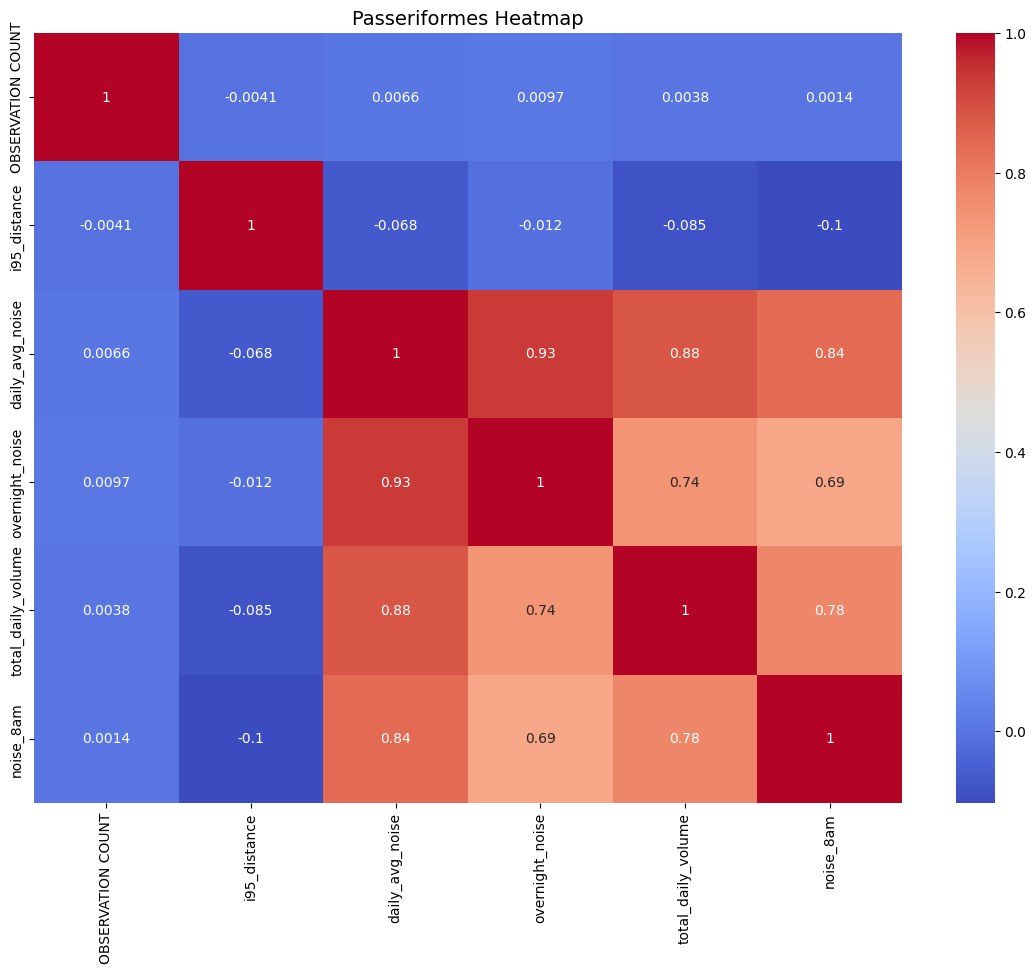

In [120]:
graph_data2 = numeric_features2.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(graph_data2, cmap="coolwarm", annot=True)
plt.title('Passeriformes Heatmap', fontsize=14)
plt.xticks(rotation=90)
plt.show()

/tmp/ipython-input-36-1304918404.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].astype('category').cat.codes


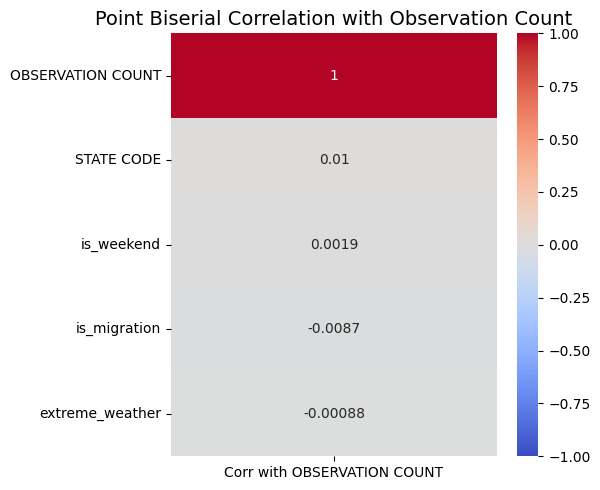

In [115]:
target = "OBSERVATION COUNT"
biserial_correlation_heatmap(sb_data, binary_features, target)

In [125]:
cat_df2 = cat_df[cat_df.Order == "Passeriformes "]

In [126]:
cat_df2.shape

(1100776, 17)

In [127]:
cat_corr2 = cat_df2.select_dtypes(include=[np.number])
cm2 = cat_corr2.corr(method='pearson')

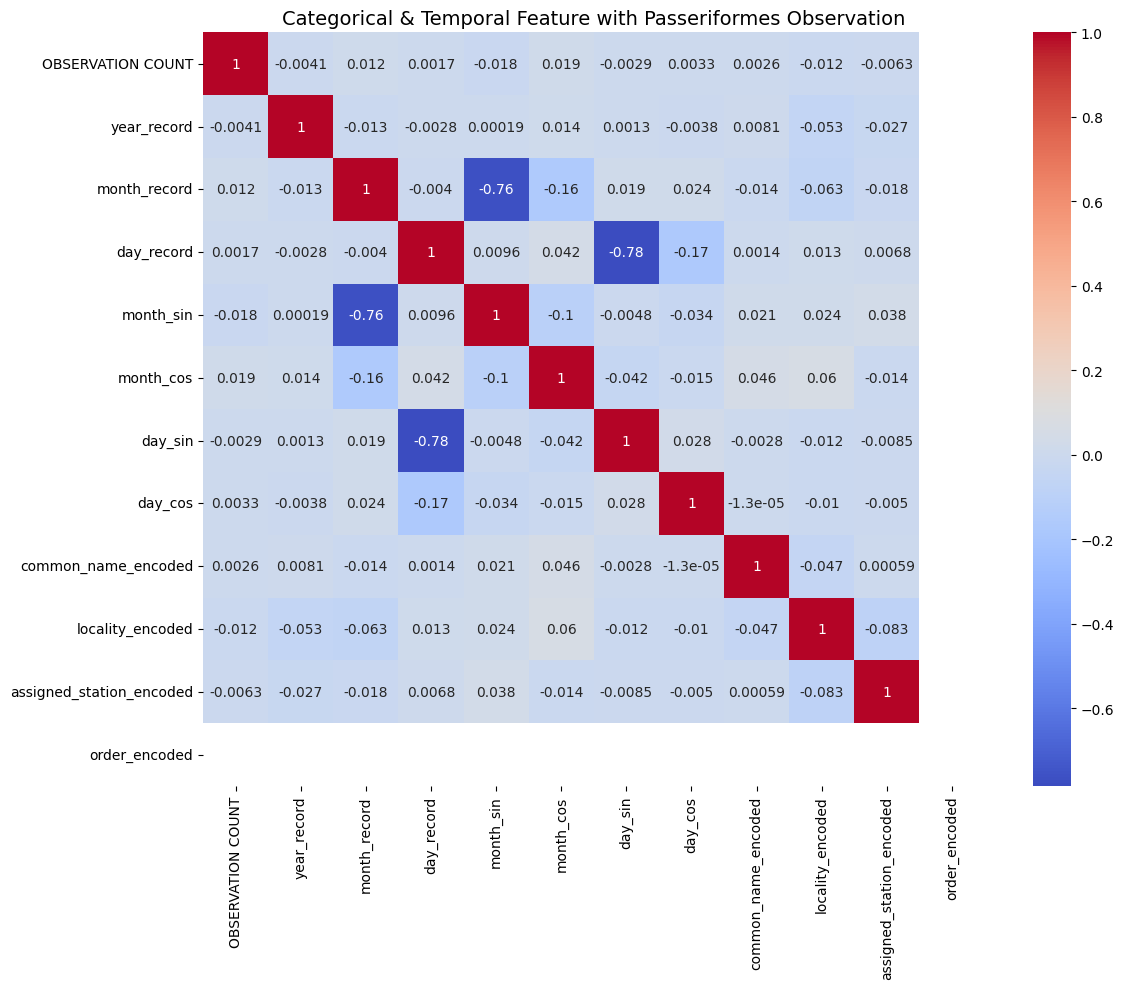

In [128]:
# Heat map
plt.figure(figsize=(12, 10))
sns.heatmap(cm2, annot=True, cmap='coolwarm')
plt.title(f'Categorical & Temporal Feature with Passeriformes Observation' , fontsize=14)
plt.tight_layout()
plt.show()

### Findings
- Filtering for Passeriformes order (Songbirds) did not result in any stengthening of the relationship strengh between our target and features.
- Among the noise related features, overnight noise consistantly has the highest correlation with the target.

In [59]:
data.columns

Index(['COMMON NAME', 'OBSERVATION COUNT', 'STATE CODE', 'LOCALITY TYPE',
       'i95_distance', 'assigned_station', 'year_record', 'month_record',
       'day_record', 'hour_started', 'daily_avg_noise', 'overnight_noise',
       'total_daily_volume', 'noise_8am', 'is_weekend', 'is_migration',
       'extreme_weather', 'Order'],
      dtype='object')

In [ ]:
ax = axes[i]
ax.scatter(df_sample[feature], df_sample["OBSERVATION COUNT"], alpha=0.6, s=30)
# ax.set_xlabel(feature, fontsize=10)
# ax.set_ylabel("Obs Cnt", fontsize=10)
ax.set_title(f'{feature} vs {"Obs Count"}', fontsize=11, pad=10)
ax.grid(True, alpha=0.3)
# ax.tick_params(axis='both', which='major', labelsize=9)

# Hide empty subplots
for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [55]:
data.Order = data.Order.str.strip()

In [56]:
data.Order.value_counts()

Order
Passeriformes          1100776
Piciformes              133896
Anseriformes            118430
Charadriiformes         105562
Accipitriformes          58217
Columbiformes            55277
Pelecaniformes           51099
Cathartiformes           29898
Suliformes               22943
Apodiformes              15247
Coraciiformes            11855
Gaviiformes               8724
Galliformes               6552
Podicipediformes          5631
Falconiformes             5400
Gruiformes                4197
Cuculiformes              3337
Strigiformes              2585
Procellariiformes          526
Caprimulgiformes           134
Ciconiiformes               15
Phoenicopteriformes          7
Psittaciformes               2
Name: count, dtype: int64

#### Bird Category and Noise

In [71]:
mean = data.noise_8am.mean() 
mean

np.float64(91.69078049213407)

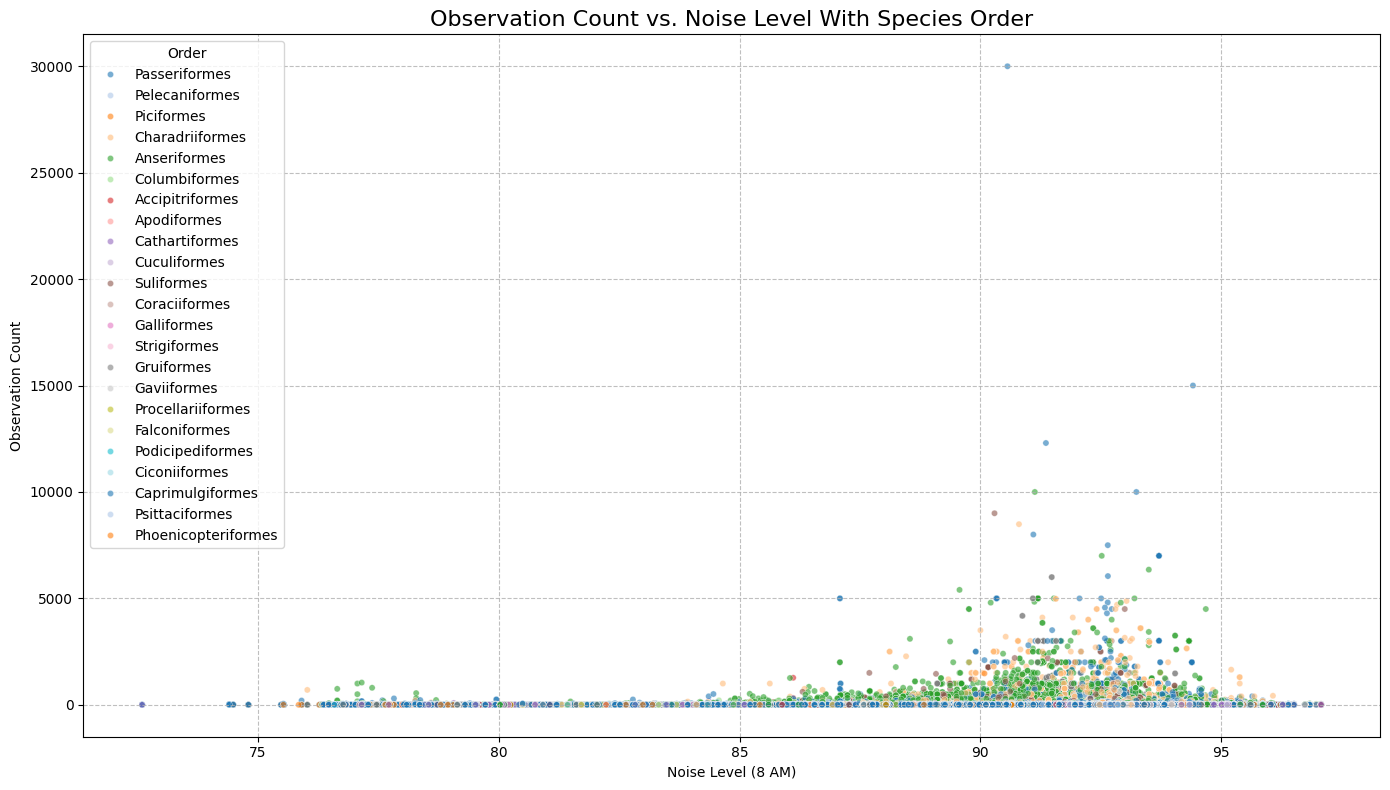

In [137]:

# Scatter plot (Observation Count Frequency)
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=data,
    x='noise_8am',
    y='OBSERVATION COUNT',
    hue='Order',
    palette = 'tab20',
    alpha=0.6,
    s=20
)

plt.title('Observation Count vs. Noise Level With Species Order', fontsize=16)
plt.xlabel('Noise Level (8 AM)')
plt.ylabel('Observation Count')
plt.grid(True, linestyle='--', alpha=0.8)
plt.tight_layout()

/var/folders/xt/_chwp0056v52sycwjk0jctdm0000gn/T/ipykernel_46985/423364067.py:20: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/sooneui/Documents/UCB_MIDS/Data/Capstone_Data/.venv/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/Users/sooneui/Documents/UCB_MIDS/Data/Capstone_Data/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


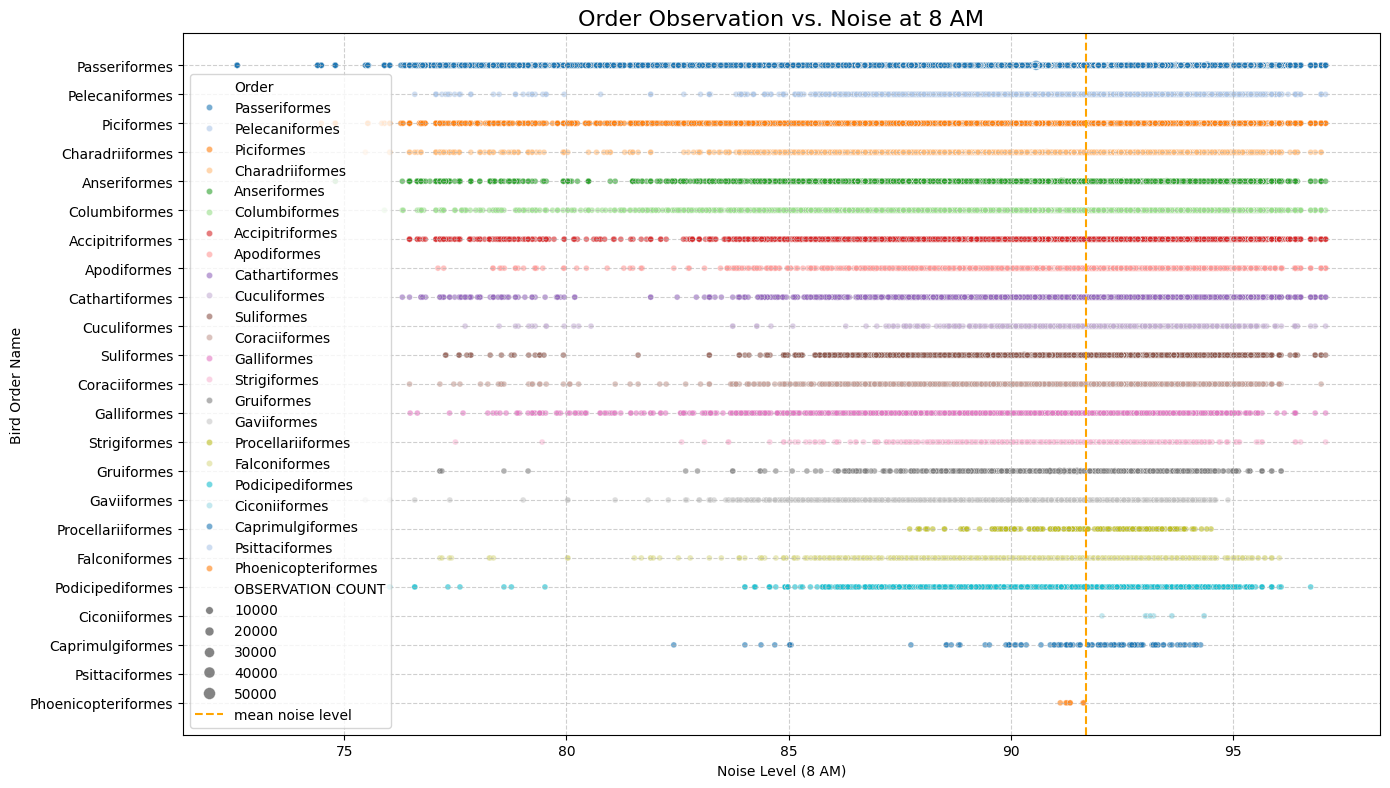

In [140]:
# Scatter plot (Observation Count Frequency)
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=data,
    x='noise_8am',
    y='Order',
    hue= 'Order',
    size='OBSERVATION COUNT',
    # sizes=(1, 75),  # Adjust size range for better visibility
    palette = 'tab20',
    alpha=0.6,
    s=20
)
plt.axvline(x=mean, color='orange', linestyle='--', label='mean noise level')
plt.title('Order Observation vs. Noise at 8 AM', fontsize=16)
plt.xlabel('Noise Level (8 AM)')
plt.ylabel('Bird Order Name')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

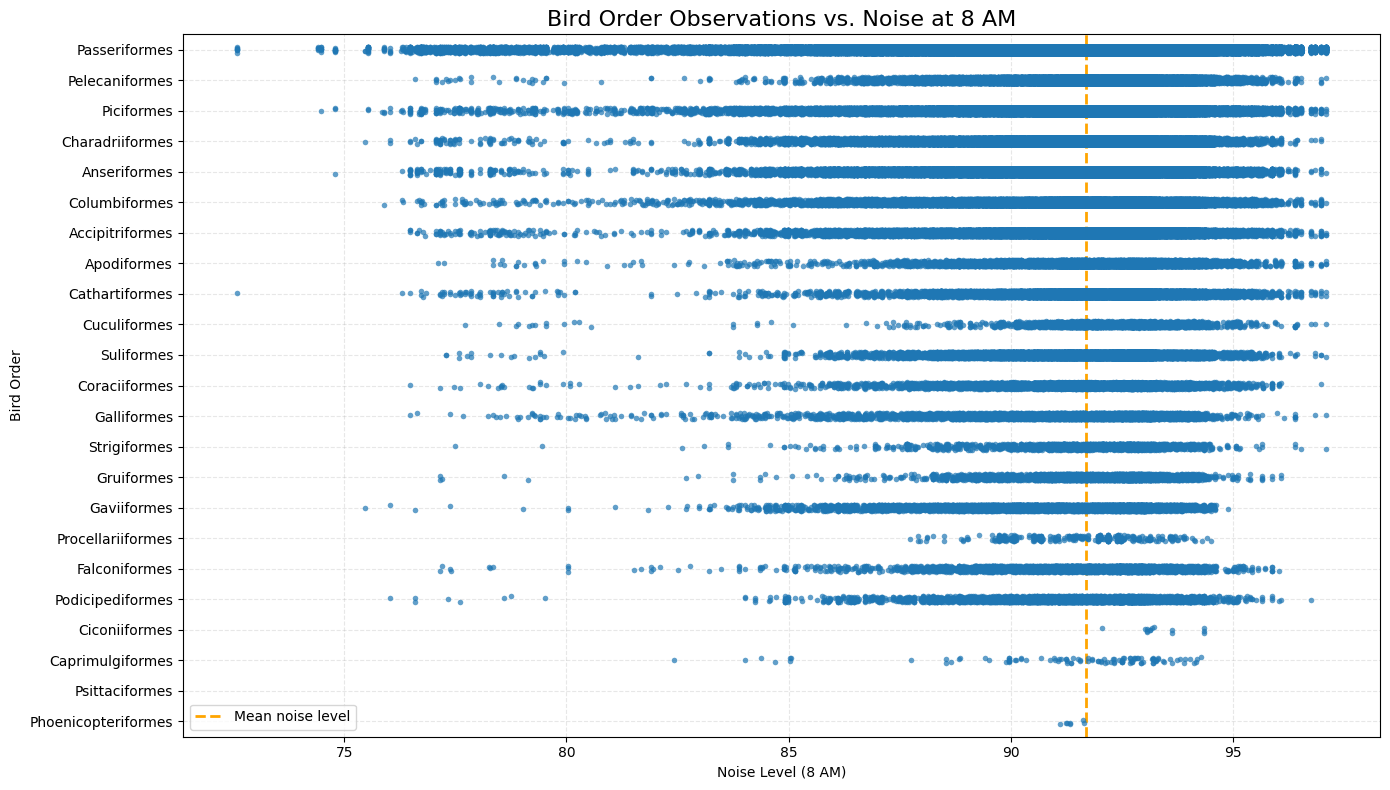

In [139]:
plt.figure(figsize=(14, 8))
sns.stripplot(
    data=data,
    x='noise_8am',
    y='Order',
    size=4,
    alpha=0.7,
    jitter=True  # Adds vertical jitter to reduce overlap
)
plt.axvline(x=mean, color='orange', linestyle='--', linewidth=2, label='Mean noise level')
plt.title('Bird Order Observations vs. Noise at 8 AM', fontsize=16)
plt.xlabel('Noise Level (8 AM)')
plt.ylabel('Bird Order')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

/var/folders/xt/_chwp0056v52sycwjk0jctdm0000gn/T/ipykernel_46985/416117138.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


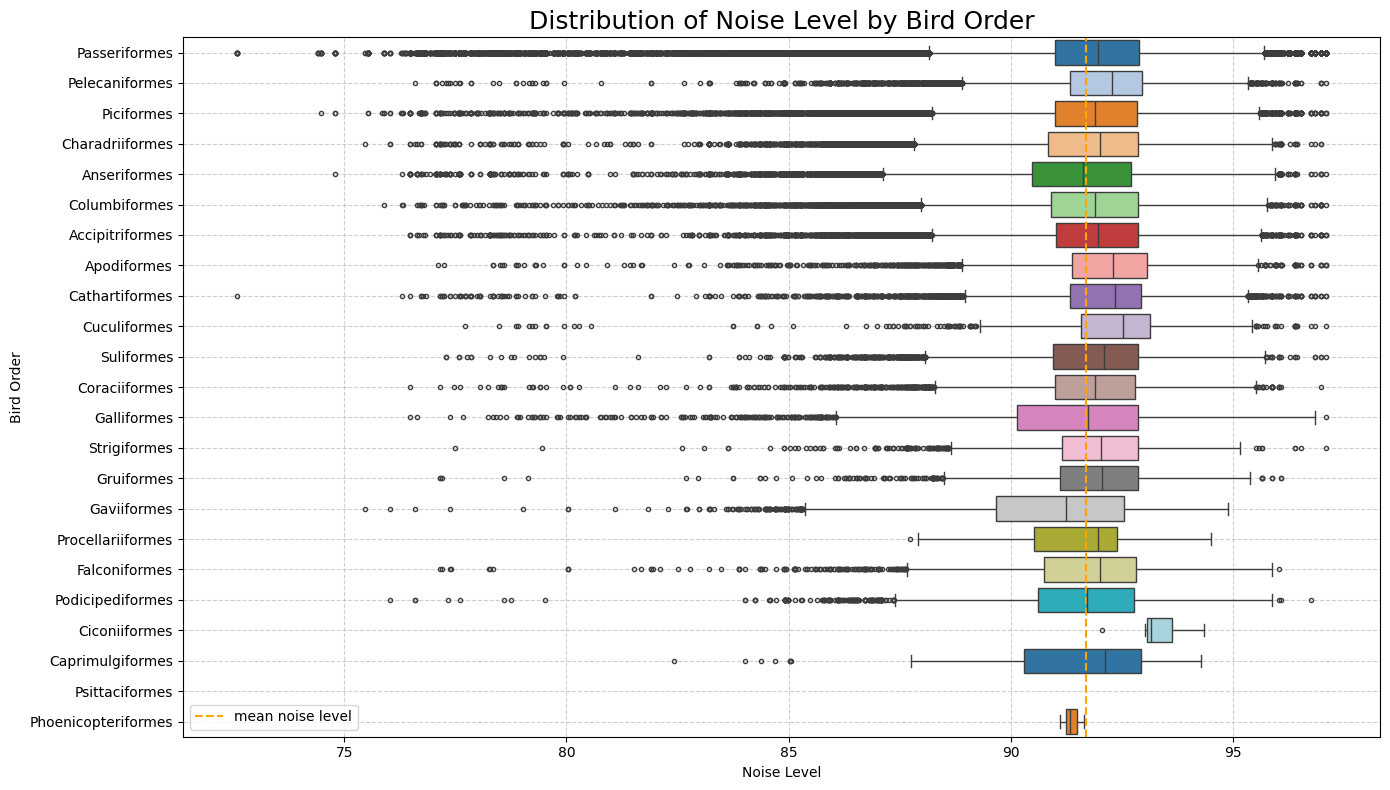

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))
sns.boxplot(
    data=data,
    x='noise_8am',
    y='Order',
    palette='tab20',
    fliersize=3,         # Size of outlier points
    linewidth=1          # Thickness of box lines
)
plt.axvline(x=mean, color='orange', linestyle='--', label='mean noise level')
plt.title('Distribution of Noise Level by Bird Order', fontsize=18)
plt.xlabel('Noise Level')
plt.ylabel('Bird Order')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


/var/folders/xt/_chwp0056v52sycwjk0jctdm0000gn/T/ipykernel_46985/2899224296.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_data = data.groupby(['noise_bin', 'Order']).agg({


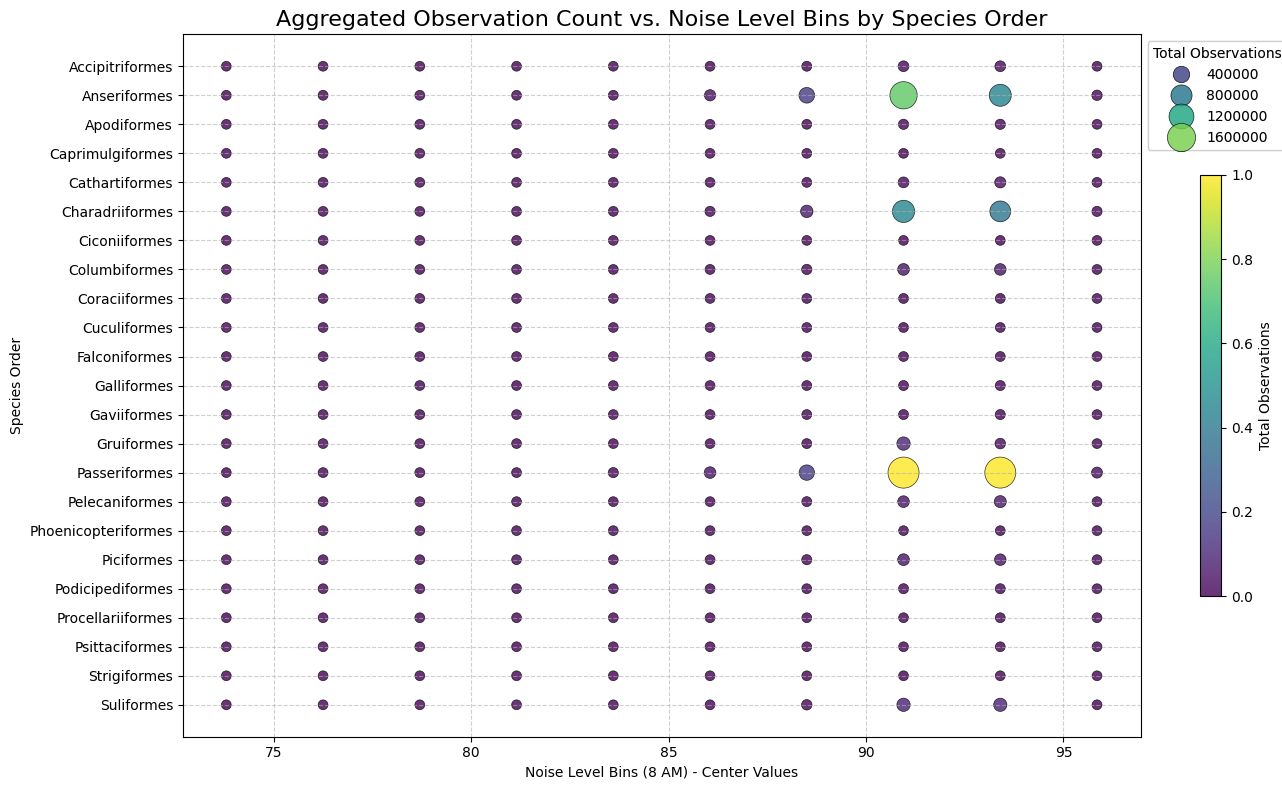

Noise level bins created:
[(72.6, 75.0], (75.0, 77.5], (77.5, 79.9], (79.9, 82.4], (82.4, 84.8], (84.8, 87.3], (87.3, 89.7], (89.7, 92.2], (92.2, 94.6], (94.6, 97.1]]
Categories (10, interval[float64, right]): [(72.6, 75.0] < (75.0, 77.5] < (77.5, 79.9] < (79.9, 82.4] ... (87.3, 89.7] < (89.7, 92.2] < (92.2, 94.6] < (94.6, 97.1]]

Total bins: 10
Data points after binning: 230


In [ ]:
# Create bins for noise levels
data['noise_bin'] = pd.cut(data['noise_8am'], bins=10, precision=1)

# Calculate aggregated statistics for each bin and order combination
binned_data = data.groupby(['noise_bin', 'Order']).agg({
    'OBSERVATION COUNT': ['sum', 'mean', 'count']
}).reset_index()

# Flatten column names
binned_data.columns = ['noise_bin', 'Order', 'total_observations', 'avg_observations', 'num_points']

# Get bin centers for x-axis positioning
binned_data['noise_center'] = binned_data['noise_bin'].apply(lambda x: x.mid)

# Create the enhanced plot
plt.figure(figsize=(14, 8))
scatter = sns.scatterplot(
    data=binned_data,
    x='noise_center',
    y='Order',
    size='total_observations',
    hue='total_observations',
    palette='viridis',  # Color gradient based on observation count
    alpha=0.8,
    sizes=(50, 500),  # Larger size range for better visibility
    edgecolor='black',
    linewidth=0.5
)

plt.title('Aggregated Observation Count vs. Noise Level Bins by Species Order', fontsize=16)
plt.xlabel('Noise Level Bins (8 AM) - Center Values')
plt.ylabel('Species Order')
plt.grid(True, linestyle='--', alpha=0.6)

# Customize the legend
handles, labels = scatter.get_legend_handles_labels()
size_legend = plt.legend(handles[1:], labels[1:], title='Total Observations', 
                        bbox_to_anchor=(1, 1), loc='upper left')
plt.gca().add_artist(size_legend)

# Add color bar for observation count
plt.colorbar(scatter.collections[0], label='Total Observations', shrink=0.6)

plt.tight_layout()
plt.show()

# Optional: Print bin information for reference
print("Noise level bins created:")
print(binned_data['noise_bin'].unique())
print(f"\nTotal bins: {len(binned_data['noise_bin'].unique())}")
print(f"Data points after binning: {len(binned_data)}")

#### Observation Frequency - Low Counts

In [ ]:
obs_count = data['OBSERVATION COUNT'].value_counts().sort_index()

/tmp/ipython-input-46-2528927593.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=observation_low.index, y=observation_low.values, palette='Set3')


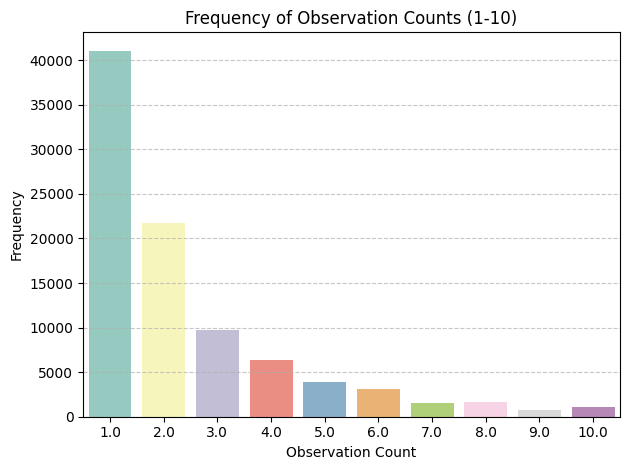

In [ ]:
observation_low = obs_count[obs_count.index <=10]

sns.barplot(x=observation_low.index, y=observation_low.values, palette='Set3')
plt.title('Frequency of Observation Counts (1-10)')
plt.xlabel('Observation Count')
plt.ylabel('Frequency')
plt.xticks()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

####Observation Frequency - Mid Counts

/tmp/ipython-input-48-3767332739.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=observation_mid.index, y=observation_mid.values, palette='Accent')


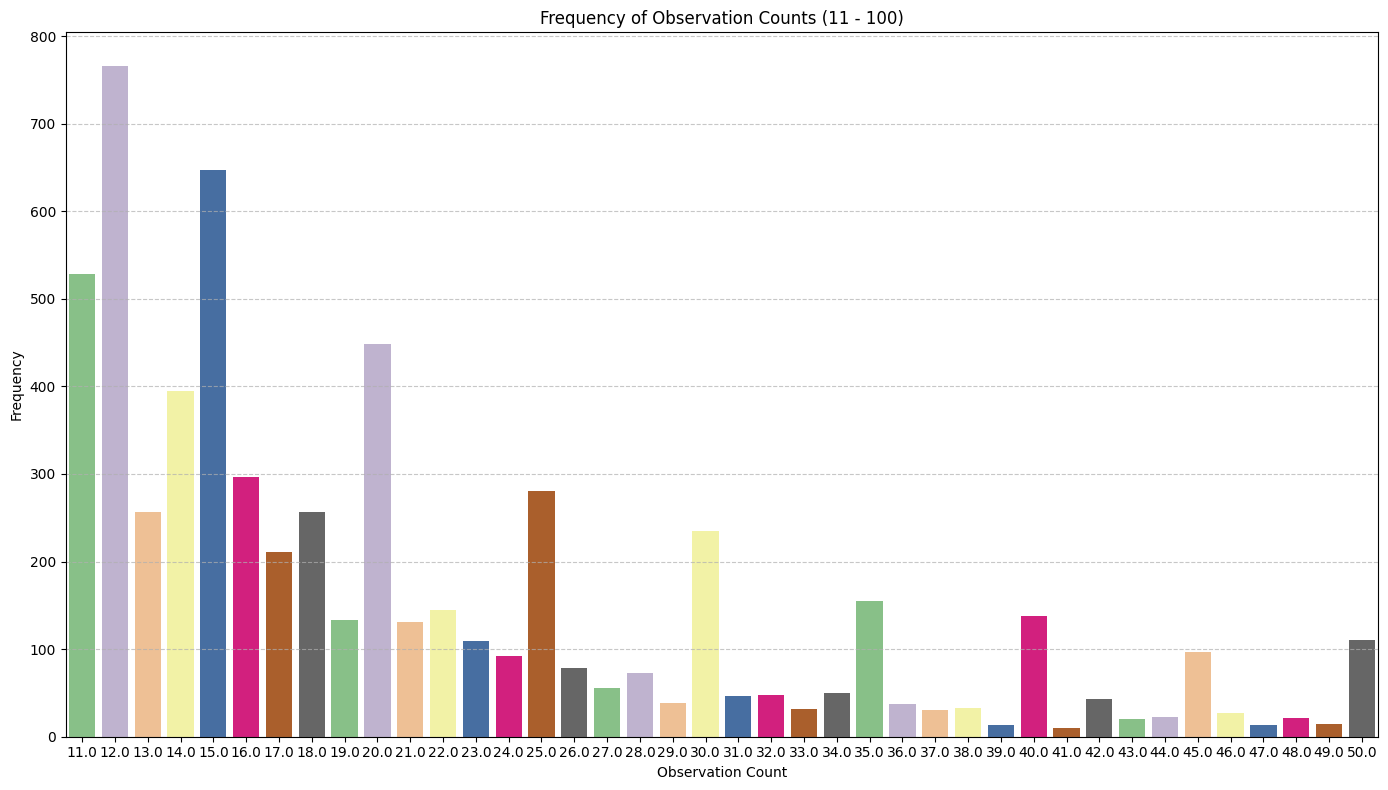

In [ ]:
observation_mid = obs_count[(obs_count.index >10) & (obs_count.index <=50)]

plt.figure(figsize=(14, 8))
sns.barplot(x=observation_mid.index, y=observation_mid.values, palette='Accent')
plt.title('Frequency of Observation Counts (11 - 100)')
plt.xlabel('Observation Count')
plt.ylabel('Frequency')
# plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

###Observation Frequency - High Counts

In [20]:
data['OBSERVATION COUNT'].min(), data['OBSERVATION COUNT'].max()

(np.float64(1.0), np.float64(50000.0))

/var/folders/xt/_chwp0056v52sycwjk0jctdm0000gn/T/ipykernel_15984/2216958713.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_data['observation_bins'] = pd.cut(sb_data['OBSERVATION COUNT'], bins=bins, labels=labels, right=True)
/var/folders/xt/_chwp0056v52sycwjk0jctdm0000gn/T/ipykernel_15984/2216958713.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=selected_binned_frequencies.index, y=selected_binned_frequencies.values, palette='Set3')


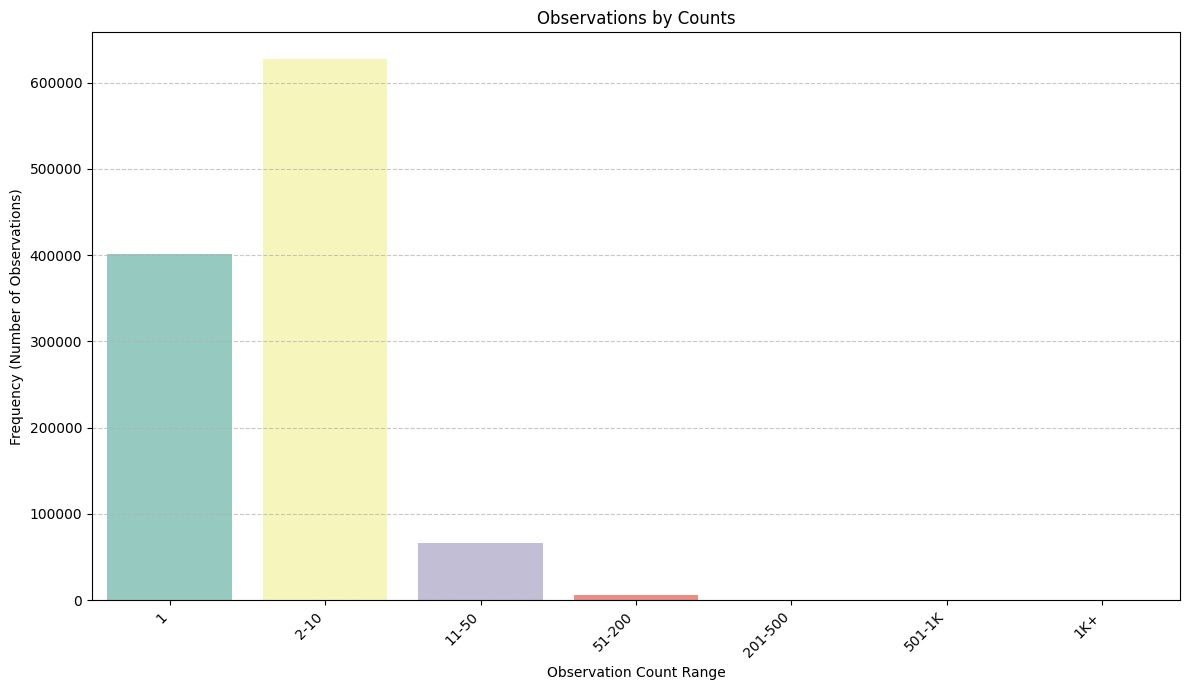

In [17]:
bins = [0, 1, 10, 50, 200, 500, 1000, sb_data['OBSERVATION COUNT'].max()+1]
labels = ['1', '2-10', '11-50', '51-200', '201-500', '501-1K', '1K+']
sb_data['observation_bins'] = pd.cut(sb_data['OBSERVATION COUNT'], bins=bins, labels=labels, right=True)
binned_frequencies = sb_data['observation_bins'].value_counts().reindex(labels)

bins_to_plot = ['1', '2-10', '11-50', '51-200', '201-500', '501-1K', '1K+']
selected_binned_frequencies = binned_frequencies[bins_to_plot]

plt.figure(figsize=(12, 7))
sns.barplot(x=selected_binned_frequencies.index, y=selected_binned_frequencies.values, palette='Set3')

plt.title('Observations by Counts')
plt.xlabel('Observation Count Range')
plt.ylabel('Frequency (Number of Observations)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

/var/folders/xt/_chwp0056v52sycwjk0jctdm0000gn/T/ipykernel_15984/3665760409.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=selected_binned_frequencies.index, y=selected_binned_frequencies.values, palette='Set3')


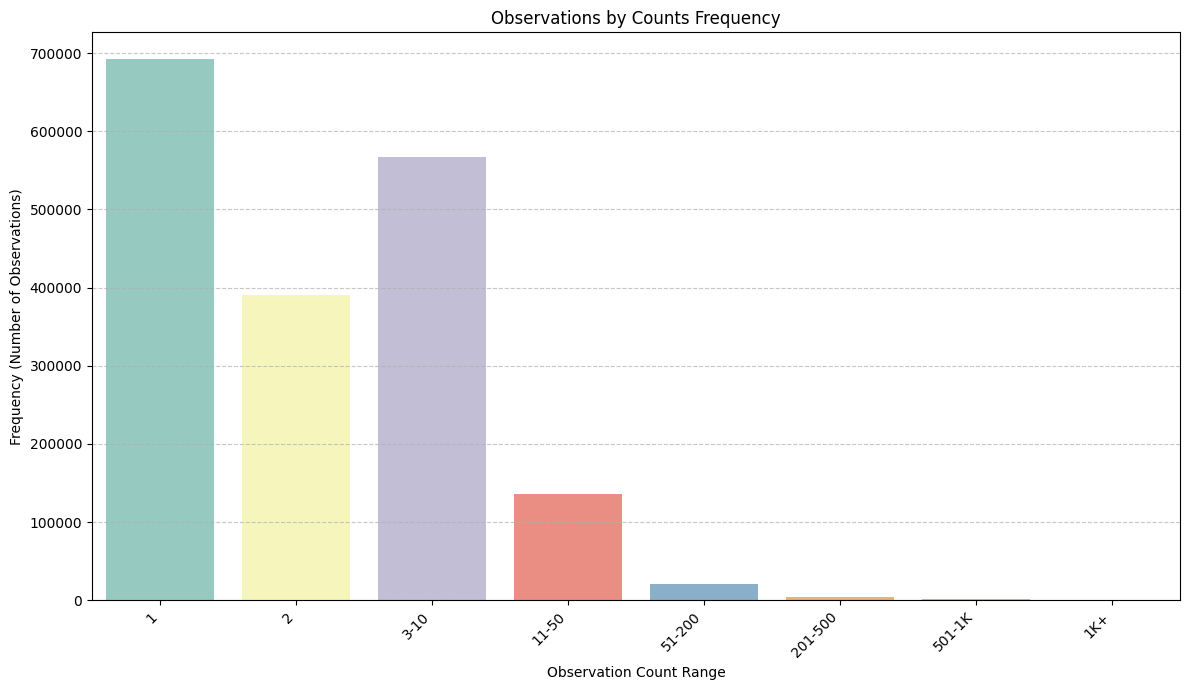

In [25]:
bins = [0, 1, 2, 10, 50, 200, 500, 1000, data['OBSERVATION COUNT'].max()+1]
labels = ['1', '2', '3-10', '11-50', '51-200', '201-500', '501-1K', '1K+']
data['observation_bins'] = pd.cut(data['OBSERVATION COUNT'], bins=bins, labels=labels, right=True)
binned_frequencies = data['observation_bins'].value_counts().reindex(labels)

bins_to_plot = ['1', '2', '3-10', '11-50', '51-200', '201-500', '501-1K', '1K+']
selected_binned_frequencies = binned_frequencies[bins_to_plot]

plt.figure(figsize=(12, 7))
sns.barplot(x=selected_binned_frequencies.index, y=selected_binned_frequencies.values, palette='Set3')

plt.title('Observations by Counts Frequency')
plt.xlabel('Observation Count Range')
plt.ylabel('Frequency (Number of Observations)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

In [36]:
subset['OBSERVATION COUNT'].max()

np.float64(75.0)

/var/folders/xt/_chwp0056v52sycwjk0jctdm0000gn/T/ipykernel_15984/89605074.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['observation_bins'] = pd.cut(subset['OBSERVATION COUNT'], bins=bins, labels=labels, right=True)
/var/folders/xt/_chwp0056v52sycwjk0jctdm0000gn/T/ipykernel_15984/89605074.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subset_frequencies.index, y=subset_frequencies.values, palette='Set3')


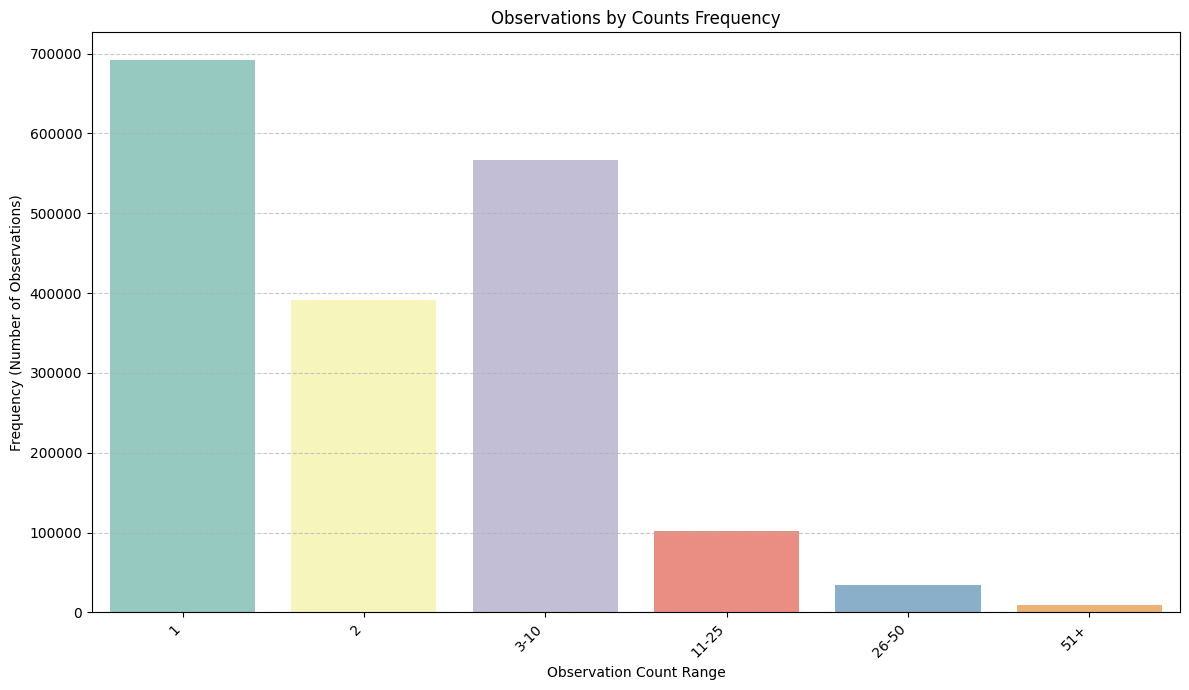

In [37]:
threshold = data['OBSERVATION COUNT'].quantile(0.99)
subset = data[data['OBSERVATION COUNT'] <= threshold]

bins = [0, 1, 2, 10, 25, 50, subset['OBSERVATION COUNT'].max()+1]
labels = ['1', '2', '3-10', '11-25', '26-50', '51+']

subset['observation_bins'] = pd.cut(subset['OBSERVATION COUNT'], bins=bins, labels=labels, right=True)
subset_frequencies = subset['observation_bins'].value_counts().reindex(labels)


plt.figure(figsize=(12, 7))
sns.barplot(x=subset_frequencies.index, y=subset_frequencies.values, palette='Set3')

plt.title('Observations by Counts Frequency')
plt.xlabel('Observation Count Range')
plt.ylabel('Frequency (Number of Observations)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Quantile values:
25.0th percentile: 1
50.0th percentile: 2
75.0th percentile: 4
99.0th percentile: 75


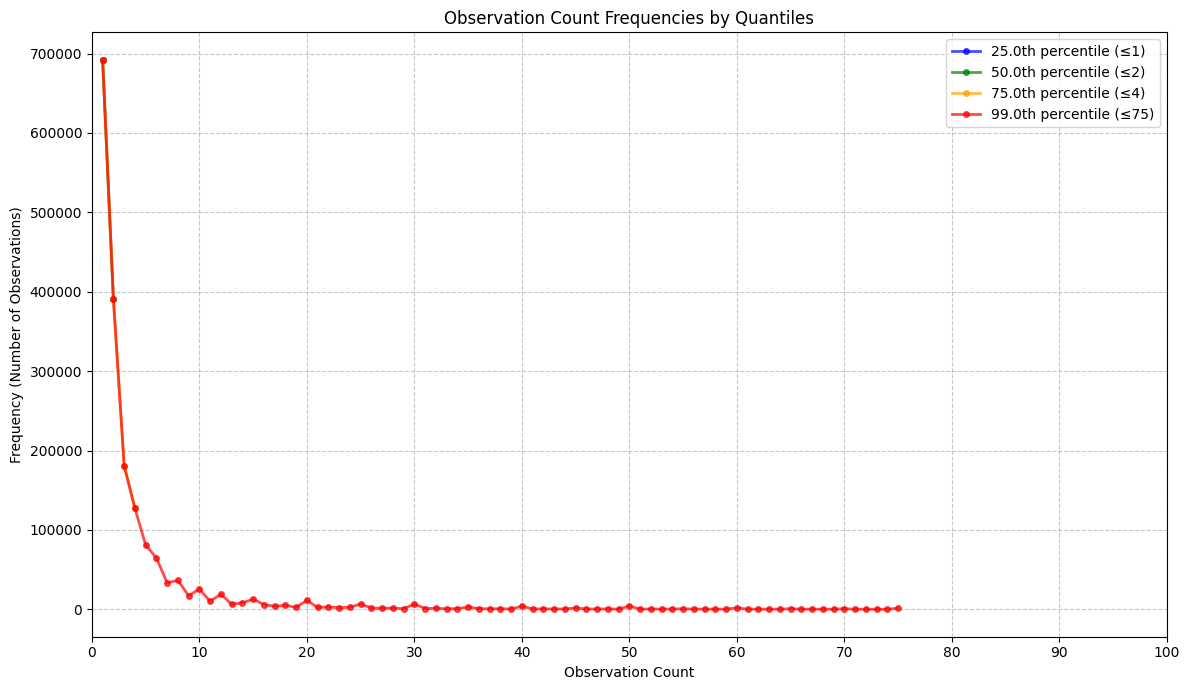

In [40]:

# Calculate quantiles for OBSERVATION COUNT
quantiles = [0.25, 0.50, 0.75, 0.99]
quantile_values = data['OBSERVATION COUNT'].quantile(quantiles)

print("Quantile values:")
for q, val in zip(quantiles, quantile_values):
    print(f"{q*100}th percentile: {val:.0f}")

# Create subsets for each quantile and calculate frequencies
quantile_data = {}
colors = ['blue', 'green', 'orange', 'red']

plt.figure(figsize=(12, 7))

for i, (q, color) in enumerate(zip(quantiles, colors)):
    # Filter data up to each quantile
    subset = data[data['OBSERVATION COUNT'] <= quantile_values[q]]
    
    # Get value counts - assuming you want to count observations by their actual count values
    # If you need binning, uncomment the next line and adjust as needed
    # subset_frequencies = pd.cut(subset['OBSERVATION COUNT'], bins=20).value_counts().sort_index()
    
    # For direct observation count frequencies:
    subset_frequencies = subset['OBSERVATION COUNT'].value_counts().sort_index()
    
    # Plot line for this quantile
    plt.plot(subset_frequencies.index, subset_frequencies.values, 
             marker='o', linewidth=2, markersize=4, 
             label=f'{q*100}th percentile (≤{quantile_values[q]:.0f})', 
             color=color, alpha=0.7)

plt.title('Observation Count Frequencies by Quantiles')
plt.xlabel('Observation Count')
plt.ylabel('Frequency (Number of Observations)')
plt.xlim(0, 100)  # Set x-axis range from 0 to 100
plt.xticks(range(0, 101, 10))  # X-ticks every 10 from 0 to 100
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Experiment Data

In [ ]:
data.columns

Index(['OBSERVATION COUNT', 'STATE CODE', 'LOCALITY TYPE', 'LATITUDE',
       'LONGITUDE', 'OBSERVATION DATE', 'TIME OBSERVATIONS STARTED',
       'i95_distance', 'station_distances', 'assigned_station', 'year_record',
       'month_record', 'day_record', 'hour_started', 'state_code',
       'day_of_week', 'latitude', 'longitude', 'station_location', 'state',
       'hour_00', 'hour_01', 'hour_02', 'hour_03', 'hour_04', 'hour_05',
       'hour_06', 'hour_07', 'hour_08', 'hour_09', 'hour_10', 'hour_11',
       'hour_12', 'hour_13', 'hour_14', 'hour_15', 'hour_16', 'hour_17',
       'hour_18', 'hour_19', 'hour_20', 'hour_21', 'hour_22', 'hour_23',
       'record_type', 'f_system', 'restrictions', 'daily_avg_noise',
       'peak_hour_noise', 'overnight_noise', 'rush_hour_noise',
       'total_daily_volume', 'noise_8am', 'is_weekend', 'is_migration',
       'extreme_weather', 'observation_bins'],
      dtype='object')

In [ ]:
exp_data = data[['OBSERVATION COUNT', 'STATE CODE', 'LOCALITY TYPE', 'LATITUDE',
       'LONGITUDE', 'OBSERVATION DATE', 'TIME OBSERVATIONS STARTED',
       'i95_distance','assigned_station', 'year_record', 'month_record',
       'day_record', 'hour_started', 'day_of_week','daily_avg_noise', 'peak_hour_noise', 'overnight_noise',
       'rush_hour_noise', 'total_daily_volume', 'noise_8am', 'is_weekend',
       'is_migration', 'extreme_weather', 'observation_bins']]

In [ ]:
exp_data.shape

(98501, 24)

In [ ]:
exp_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98501 entries, 0 to 132075
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   OBSERVATION COUNT          98501 non-null  float64       
 1   STATE CODE                 98501 non-null  int8          
 2   LOCALITY TYPE              98501 non-null  object        
 3   LATITUDE                   98501 non-null  float64       
 4   LONGITUDE                  98501 non-null  float64       
 5   OBSERVATION DATE           98501 non-null  datetime64[ns]
 6   TIME OBSERVATIONS STARTED  98501 non-null  object        
 7   i95_distance               98501 non-null  float64       
 8   assigned_station           98501 non-null  object        
 9   year_record                98501 non-null  int32         
 10  month_record               98501 non-null  int8          
 11  day_record                 98501 non-null  int8          
 12  hour_sta

In [ ]:
exp_data.to_parquet("exp_data_20250701.parquet")

In [ ]:
daily_sum = exp_data.groupby('OBSERVATION DATE')['OBSERVATION COUNT'].sum().reset_index()
daily_sum.rename(columns={'OBSERVATION COUNT': 'DAILY OBSERVATION TOTAL'}, inplace=True)
daily_sum_sorted = daily_sum.sort_values(by='DAILY OBSERVATION TOTAL', ascending=False).reset_index(drop=True)
print(daily_sum_sorted.head(20))


   OBSERVATION DATE  DAILY OBSERVATION TOTAL
0        2021-01-03                   6458.0
1        2020-05-03                   3796.0
2        2022-09-11                   3624.0
3        2023-01-01                   3494.0
4        2023-10-07                   3399.0
5        2022-10-09                   3333.0
6        2023-10-30                   3103.0
7        2023-10-08                   2982.0
8        2022-08-14                   2863.0
9        2023-10-15                   2651.0
10       2023-12-31                   2563.0
11       2020-04-05                   2454.0
12       2021-11-07                   2379.0
13       2022-03-19                   2246.0
14       2022-10-15                   2200.0
15       2023-10-06                   2170.0
16       2023-10-31                   2089.0
17       2020-04-29                   2083.0
18       2021-01-22                   1931.0
19       2020-05-15                   1915.0


In [ ]:
daily_count = exp_data.groupby('OBSERVATION DATE')['OBSERVATION COUNT']
daily_count.value_counts().nlargest(10)

,,count
OBSERVATION DATE,OBSERVATION COUNT,
2023-05-06,1.0,243
2022-05-14,1.0,224
2022-04-23,1.0,205
2023-05-13,1.0,188
2021-05-08,1.0,178
2022-05-06,1.0,175
2023-04-29,1.0,175
2022-06-07,1.0,169
2023-05-12,1.0,168


### Filtering for i95 distance < 0.5

In [82]:
data.columns

Index(['COMMON NAME', 'OBSERVATION COUNT', 'STATE CODE', 'LOCALITY TYPE',
       'i95_distance', 'assigned_station', 'year_record', 'month_record',
       'day_record', 'hour_started', 'daily_avg_noise', 'overnight_noise',
       'total_daily_volume', 'noise_8am', 'is_weekend', 'is_migration',
       'extreme_weather', 'Order', 'noise_bin'],
      dtype='object')

In [83]:
data_25 = data[data['i95_distance'] <= 0.25]

In [84]:
data_25.shape

(1049346, 19)

In [96]:
data_25.i95_distance.max()

np.float64(0.24998594023370932)

/var/folders/xt/_chwp0056v52sycwjk0jctdm0000gn/T/ipykernel_46985/1753597804.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


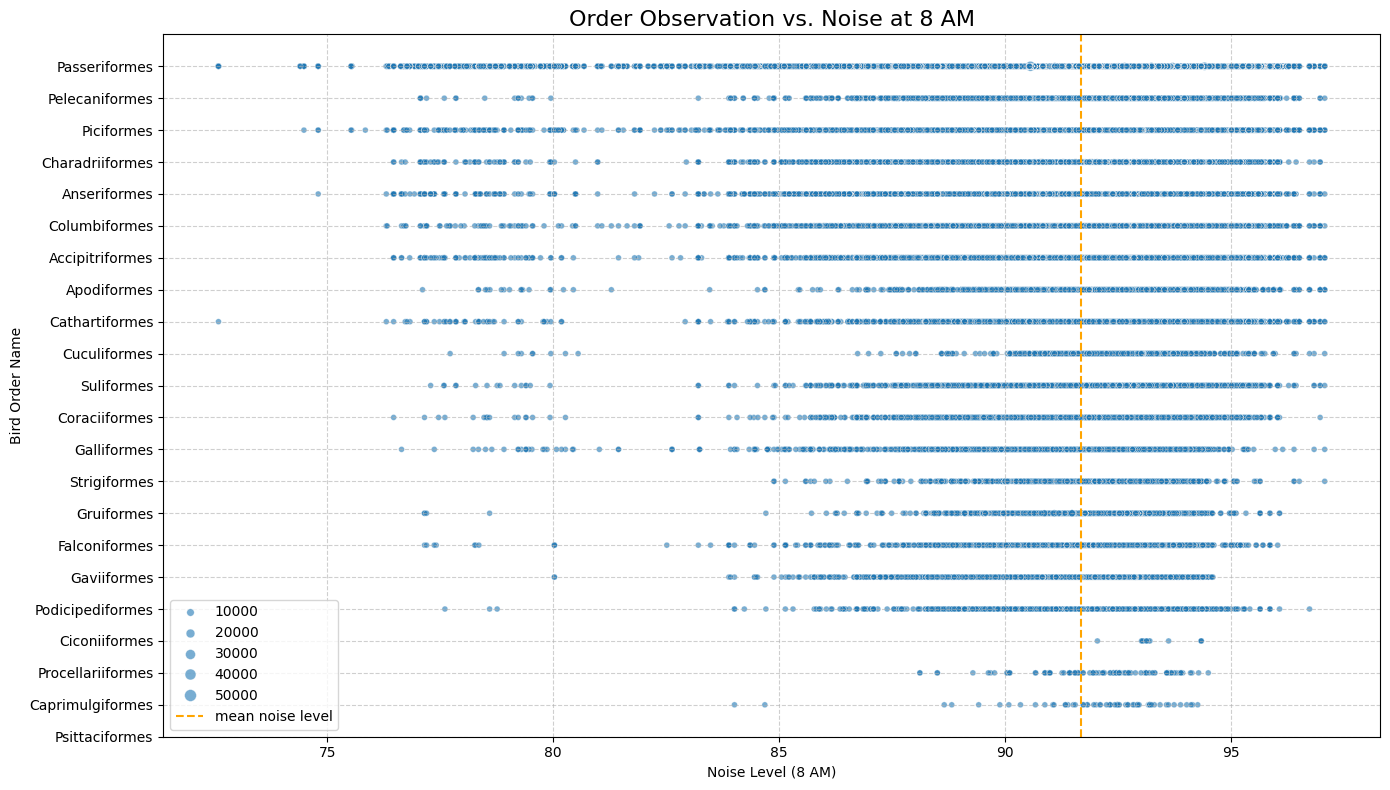

In [85]:
# Scatter plot (Observation Count Frequency)
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=data_25,
    x='noise_8am',
    y='Order',
    # hue= 'OBSERVATION COUNT',
    size='OBSERVATION COUNT',
    # sizes=(1, 75),  # Adjust size range for better visibility
    palette = 'tab20',
    alpha=0.6,
    s=20
)
plt.axvline(x=mean, color='orange', linestyle='--', label='mean noise level')
plt.title('Order Observation vs. Noise at 8 AM', fontsize=16)
plt.xlabel('Noise Level (8 AM)')
plt.ylabel('Bird Order Name')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

### Species within Passeriformes

In [89]:
data_pf.columns

Index(['COMMON NAME', 'OBSERVATION COUNT', 'STATE CODE', 'LOCALITY TYPE',
       'i95_distance', 'assigned_station', 'year_record', 'month_record',
       'day_record', 'hour_started', 'daily_avg_noise', 'overnight_noise',
       'total_daily_volume', 'noise_8am', 'is_weekend', 'is_migration',
       'extreme_weather', 'Order', 'noise_bin'],
      dtype='object')

In [86]:
data_pf = data[data.Order == "Passeriformes"]

/var/folders/xt/_chwp0056v52sycwjk0jctdm0000gn/T/ipykernel_46985/687946651.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


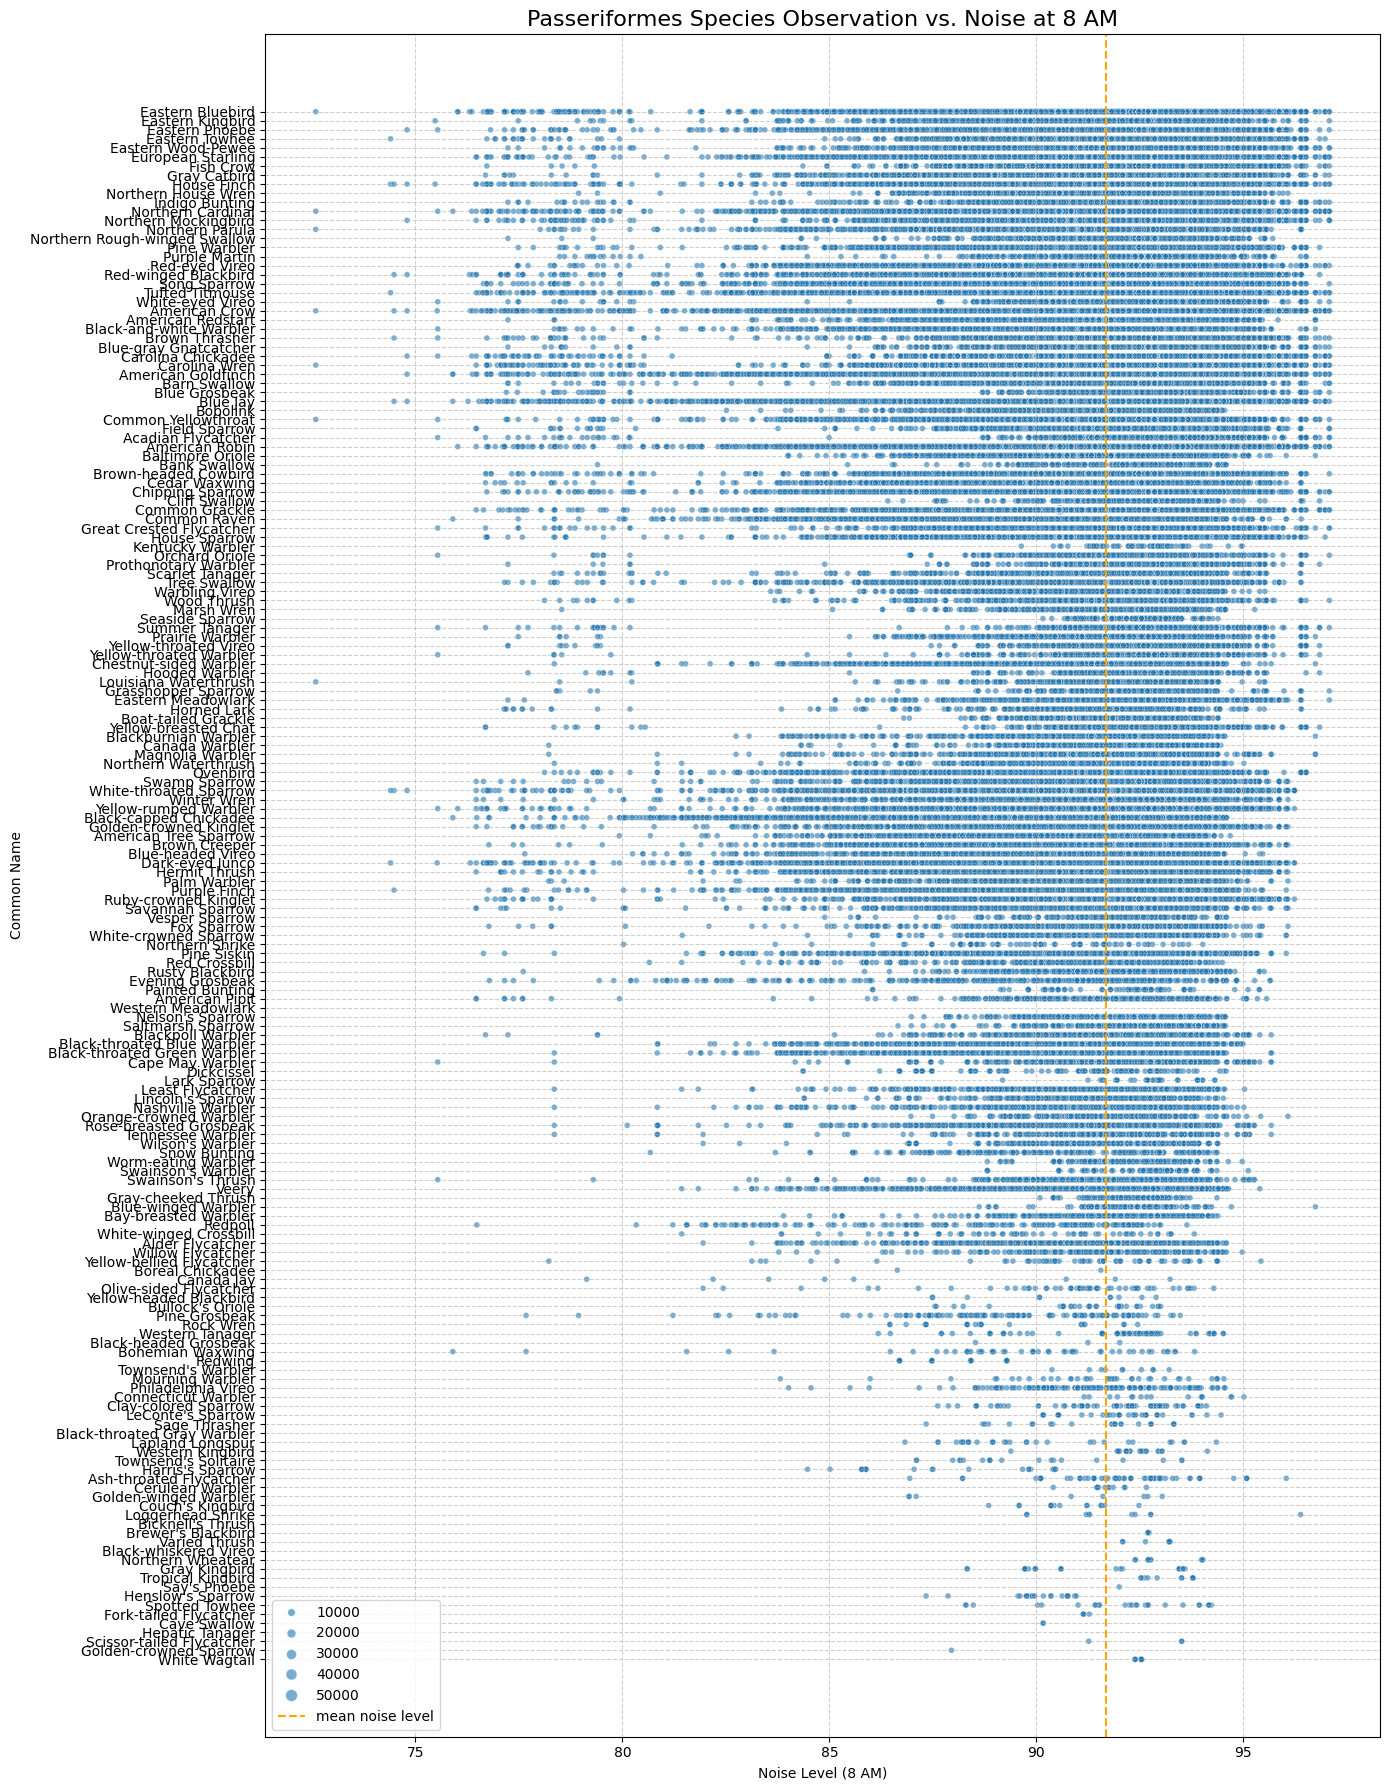

In [97]:
plt.figure(figsize=(14, 18))
sns.scatterplot(
    data=data_pf,
    x='noise_8am',
    y='COMMON NAME',
    # hue= 'OBSERVATION COUNT',
    size='OBSERVATION COUNT',
    # sizes=(1, 75),  # Adjust size range for better visibility
    palette = 'tab20',
    alpha=0.6,
    s=20
)
plt.axvline(x=mean, color='orange', linestyle='--', label='mean noise level')
plt.title('Passeriformes Species Observation vs. Noise at 8 AM', fontsize=16)
plt.xlabel('Noise Level (8 AM)')
plt.ylabel('Common Name')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

### Observations by i95 distances

In [125]:
distance_observation = data.groupby('i95_distance')['OBSERVATION COUNT'].sum().reset_index()
distance_observation.rename(columns={'OBSERVATION COUNT': 'TOTAL OBSERVATIONS'}, inplace=True)

by_order = data.groupby(['Order', 'COMMON NAME'])['OBSERVATION COUNT'].unique().reset_index()
by_order.rename(columns={'OBSERVATION COUNT': 'TOTAL OBSERVATIONS'}, inplace=True)

/var/folders/xt/_chwp0056v52sycwjk0jctdm0000gn/T/ipykernel_46985/1667018206.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


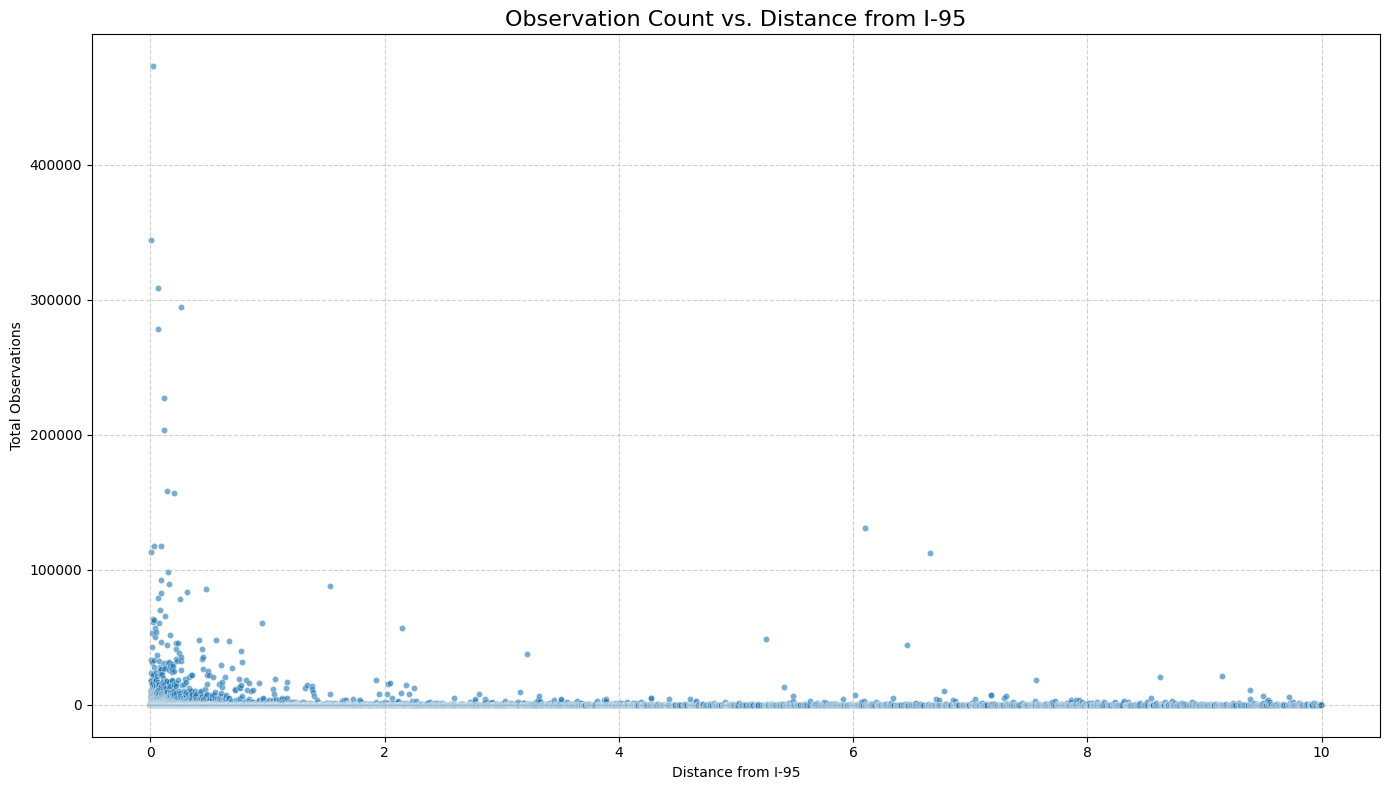

In [126]:
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=distance_observation,
    x='i95_distance',
    y='TOTAL OBSERVATIONS',
    # hue='Order',
    palette = 'tab20',
    alpha=0.6,
    s=20
)

plt.title('Observation Count vs. Distance from I-95', fontsize=16)
plt.xlabel('Distance from I-95')
plt.ylabel('Total Observations')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

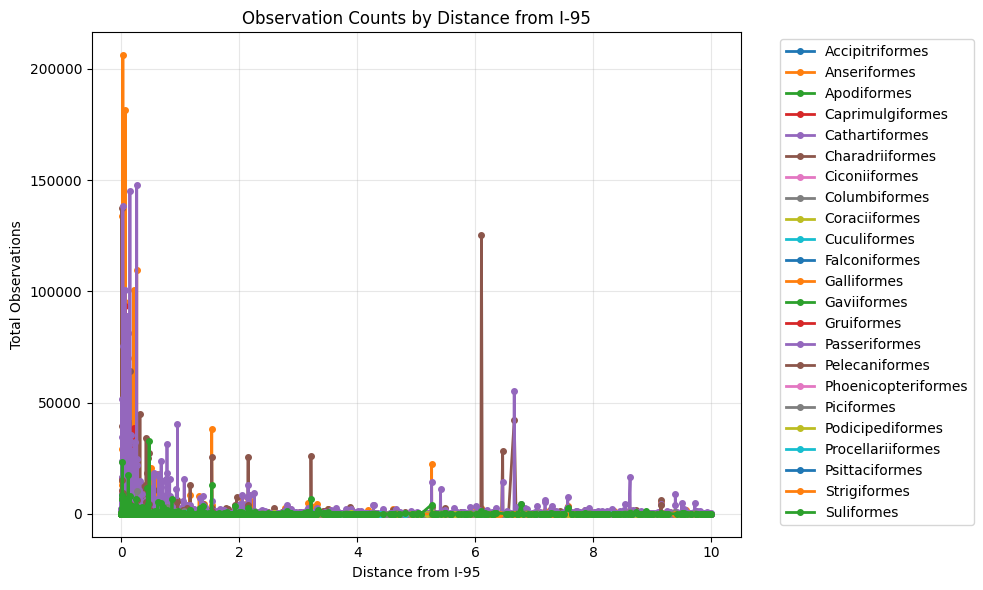

In [127]:
import matplotlib.pyplot as plt
import pandas as pd

# Aggregate your data
by_order = data.groupby(['Order', 'i95_distance'])['OBSERVATION COUNT'].sum().reset_index()
by_order.rename(columns={'OBSERVATION COUNT': 'TOTAL OBSERVATIONS'}, inplace=True)

# Create the plot
plt.figure(figsize=(10, 6))

# Plot lines for each order
for order in by_order['Order'].unique():
    order_data = by_order[by_order['Order'] == order].sort_values('i95_distance')
    plt.plot(order_data['i95_distance'], order_data['TOTAL OBSERVATIONS'], 
             marker='o', label=order, linewidth=2, markersize=4)

plt.xlabel('Distance from I-95')
plt.ylabel('Total Observations')
plt.title('Observation Counts by Distance from I-95')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

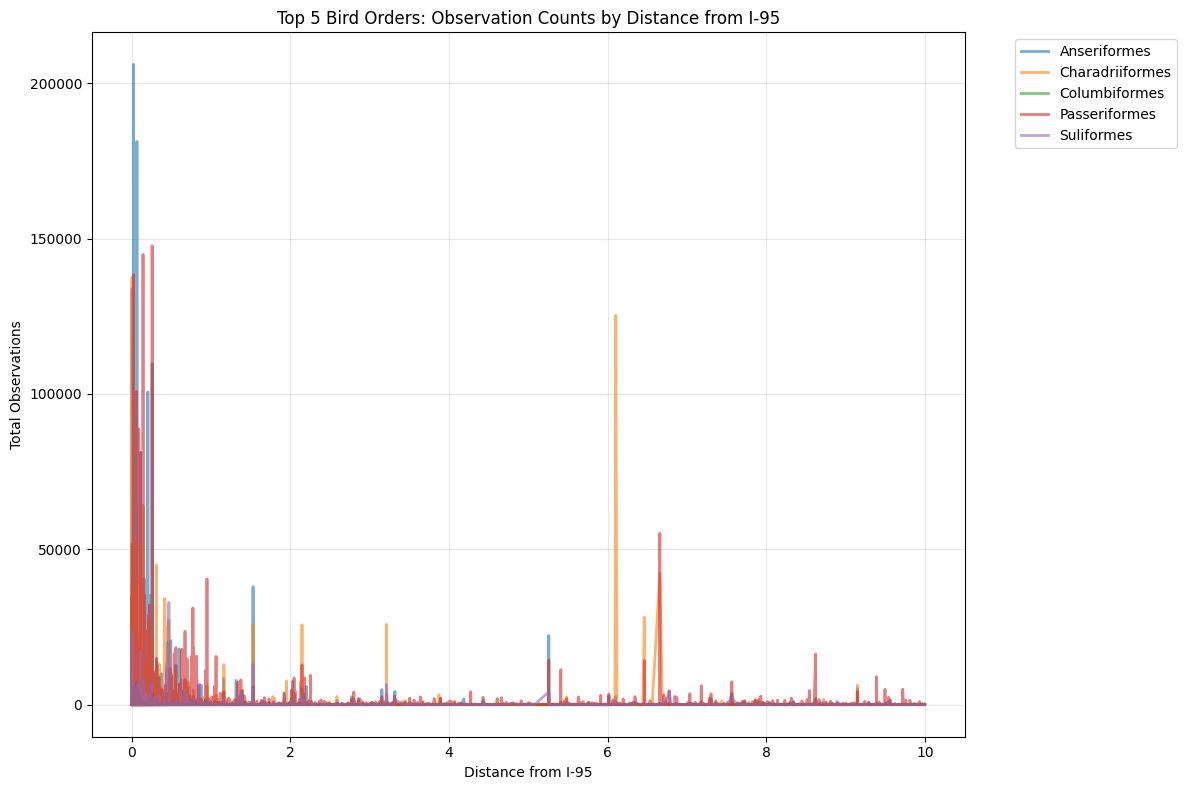

In [128]:


# top 5 orders by total observation count
top_orders = data.groupby('Order')['OBSERVATION COUNT'].sum().nlargest(5).index

# Filter data to only include top 5 orders
filtered_data = data[data['Order'].isin(top_orders)]

# Now aggregate the filtered data
by_order = filtered_data.groupby(['Order', 'i95_distance'])['OBSERVATION COUNT'].sum().reset_index()
by_order.rename(columns={'OBSERVATION COUNT': 'TOTAL OBSERVATIONS'}, inplace=True)

# Create the plot
plt.figure(figsize=(12, 8))

# Plot lines for each of the top 5 orders
for order in by_order['Order'].unique():
    order_data = by_order[by_order['Order'] == order].sort_values('i95_distance')
    plt.plot(order_data['i95_distance'], order_data['TOTAL OBSERVATIONS'], 
             marker='None', label=order, linewidth=2, markersize=4, alpha=0.6)

plt.xlabel('Distance from I-95')
plt.ylabel('Total Observations')
plt.title('Top 5 Bird Orders: Observation Counts by Distance from I-95')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

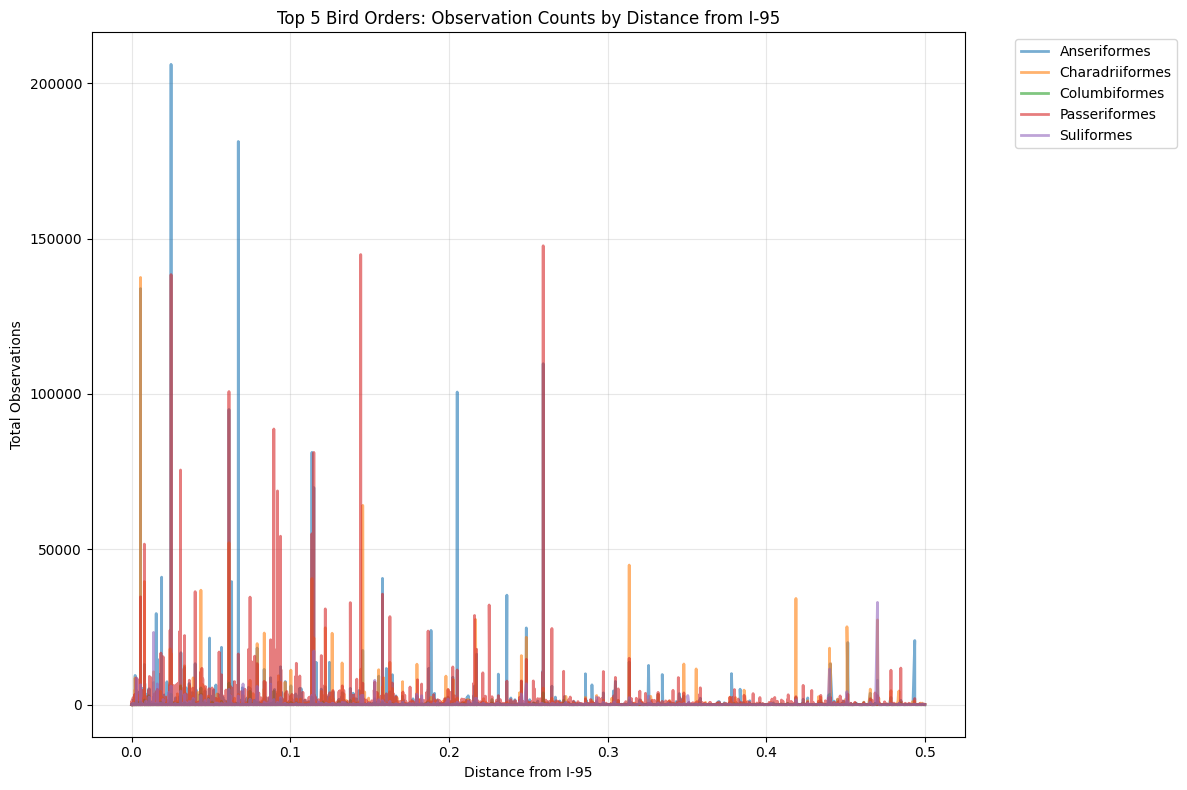

In [130]:
# top 5 orders by total observation count
top_orders = data.groupby('Order')['OBSERVATION COUNT'].sum().nlargest(5).index

# Filter data to only include top 5 orders or distances within 0.5 miles of I-95
filtered_data = data[
    data['Order'].isin(top_orders) & (data['i95_distance'] <= 0.5)
]

# Now aggregate the filtered data
by_order = filtered_data.groupby(['Order', 'i95_distance'])['OBSERVATION COUNT'].sum().reset_index()
by_order.rename(columns={'OBSERVATION COUNT': 'TOTAL OBSERVATIONS'}, inplace=True)

# Create the plot
plt.figure(figsize=(12, 8))

# Plot lines
for order in by_order['Order'].unique():
    order_data = by_order[by_order['Order'] == order].sort_values('i95_distance')
    plt.plot(order_data['i95_distance'], order_data['TOTAL OBSERVATIONS'], 
             marker='None', label=order, linewidth=2, markersize=4, alpha=0.6)

plt.xlabel('Distance from I-95')
plt.ylabel('Total Observations')
plt.title('Top 5 Bird Orders: Observation Counts by Distance from I-95')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

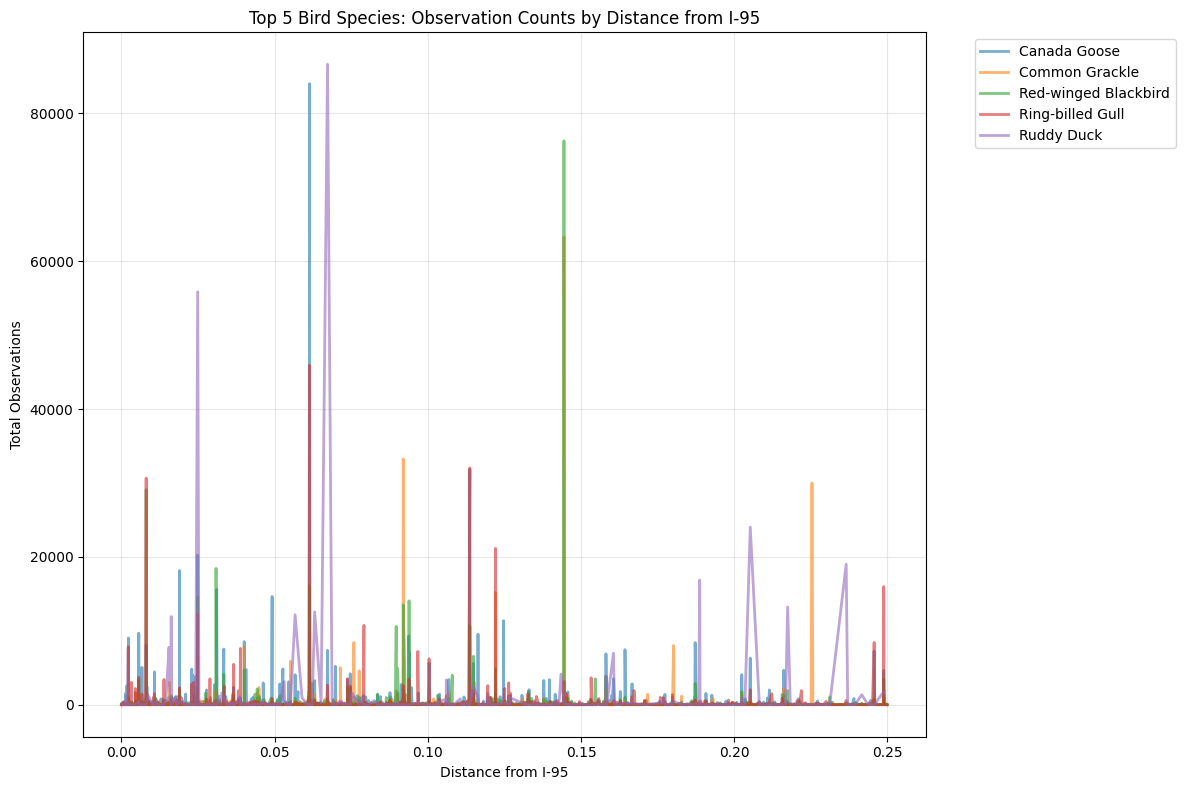

In [136]:
# data_25 = filtered data for i95_distance within 0.25 miles
# top 5 species by total observation count
top_species = data_25.groupby('COMMON NAME')['OBSERVATION COUNT'].sum().nlargest(5).index
filtered_data = data_25[data_25['COMMON NAME'].isin(top_species)]
# Aggregate the filtered data
by_species = filtered_data.groupby(['COMMON NAME', 'i95_distance'])['OBSERVATION COUNT'].sum().reset_index()
by_species.rename(columns={'OBSERVATION COUNT': 'TOTAL OBSERVATIONS'}, inplace=True)

# Create the plot
plt.figure(figsize=(12, 8))

# Plot lines
for name in by_species['COMMON NAME'].unique():
    species_data = by_species[by_species['COMMON NAME'] == name].sort_values('i95_distance')
    plt.plot(species_data['i95_distance'], species_data['TOTAL OBSERVATIONS'], 
             marker='None', label=name, linewidth=2, markersize=4, alpha=0.6)

plt.xlabel('Distance from I-95')
plt.ylabel('Total Observations')
plt.title('Top 5 Bird Species: Observation Counts by Distance from I-95')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()